In [2]:
# Importing libraries and setting random seed
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
random.seed(42)
np.random.seed(42)
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [4]:
# Load the dataset
dataset_path=Path("../dataset/diabetes_prediction_dataset_2000.csv")
df=pd.read_csv(dataset_path)
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [5]:
# Basic dataset checking
print("Dataset shape:",df.shape)
print("\nDataset information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:",df.duplicated().sum())

Dataset shape: (2000, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               2000 non-null   object 
 1   age                  2000 non-null   float64
 2   hypertension         2000 non-null   int64  
 3   heart_disease        2000 non-null   int64  
 4   smoking_history      2000 non-null   object 
 5   bmi                  2000 non-null   float64
 6   HbA1c_level          2000 non-null   float64
 7   blood_glucose_level  2000 non-null   int64  
 8   diabetes             2000 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 140.8+ KB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes   

In [6]:
# Separate features and target
X=df.drop("diabetes",axis=1)
y=df["diabetes"]
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  13.0             0              0         No Info  20.82   
1  Female   3.0             0              0         No Info  21.00   
2    Male  63.0             0              0          former  25.32   
3  Female   2.0             0              0           never  17.43   
4  Female  33.0             0              0     not current  40.08   

   HbA1c_level  blood_glucose_level  
0          5.8                  126  
1          5.0                  145  
2          3.5                  200  
3          6.1                  126  
4          6.2                  200  

Target:
0    0
1    0
2    0
3    0
4    1
Name: diabetes, dtype: int64


In [7]:
# Identify numerical and categorical columns
numeric_features=X.select_dtypes(include=["int64","float64"]).columns
categorical_features=X.select_dtypes(include=["object","category"]).columns
print("Numerical features:")
print(list(numeric_features))
print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Categorical features:
['gender', 'smoking_history']


In [8]:
# Preprocessing
preprocessor=ColumnTransformer(transformers=[
    ("numerical",StandardScaler(),numeric_features),
    ("categorical",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical_features)
])

In [9]:
# Split the dataset into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    
)
print("Training set:",x_train.shape)
print("Testing set:",x_test.shape)

Training set: (1600, 8)
Testing set: (400, 8)


In [10]:
# Create Support Vector Machine Classifier
svm_model=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("svm",SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42))
])
svm_model

,steps,"[('preprocessing', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# Train the SVM model
svm_model.fit(x_train,y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [12]:
# Make predictions
svm_pred=svm_model.predict(x_test)
svm_prob=svm_model.predict_proba(x_test)[:,1]
print("Predictions:")
print(svm_pred[:10])

Predictions:
[0 0 1 0 0 0 1 0 0 0]


In [14]:
# Calculate evaluation metrics
svm_accuracy=accuracy_score(y_test,svm_pred)
svm_precision=precision_score(y_test,svm_pred,zero_division=0)
svm_recall=recall_score(y_test,svm_pred,zero_division=0)
svm_f1=f1_score(y_test,svm_pred,average="weighted")
svm_auc=roc_auc_score(y_test,svm_prob)
print("Support Vector Machine Performance")
print("Accuracy:",round(svm_accuracy,4))
print("Precision:",round(svm_precision,4))
print("Recall:",round(svm_recall,4))
print("Weighted F1:",round(svm_f1,4))
print("ROC-AUC:",round(svm_auc,4))

Support Vector Machine Performance
Accuracy: 0.9575
Precision: 0.9524
Recall: 0.5556
Weighted F1: 0.9523
ROC-AUC: 0.9571


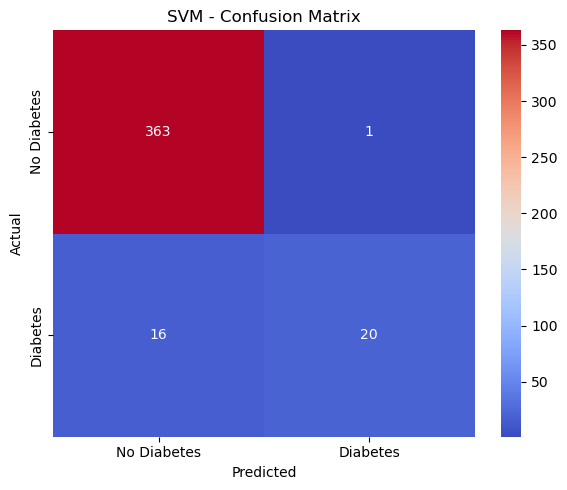

In [16]:
# Confusion Matrix
cm_svm=confusion_matrix(y_test,svm_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,annot=True,fmt="d",cmap="coolwarm",xticklabels=["No Diabetes","Diabetes"],yticklabels=["No Diabetes","Diabetes"])
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

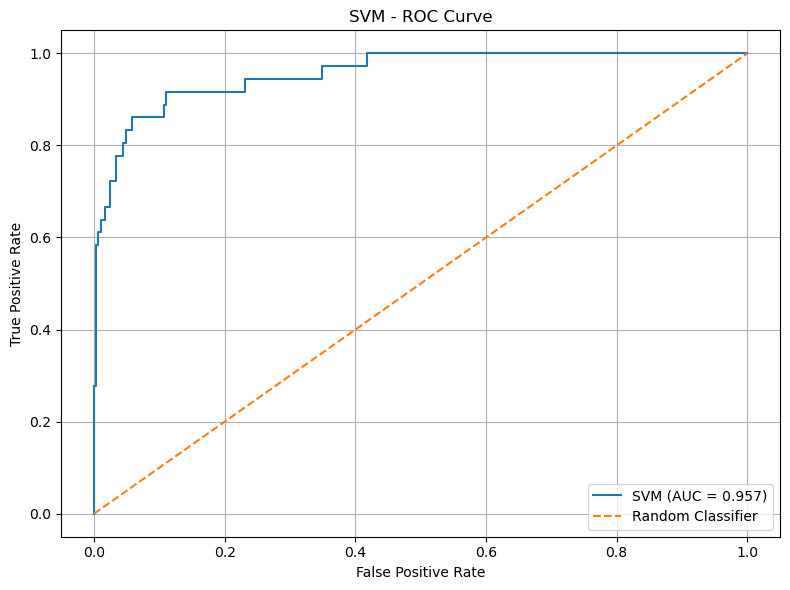

In [17]:
# ROC Curve
svm_fpr,svm_tpr,_=roc_curve(y_test,svm_prob)
plt.figure(figsize=(8,6))
plt.plot(svm_fpr,svm_tpr,label=f"SVM (AUC = {svm_auc:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM - ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


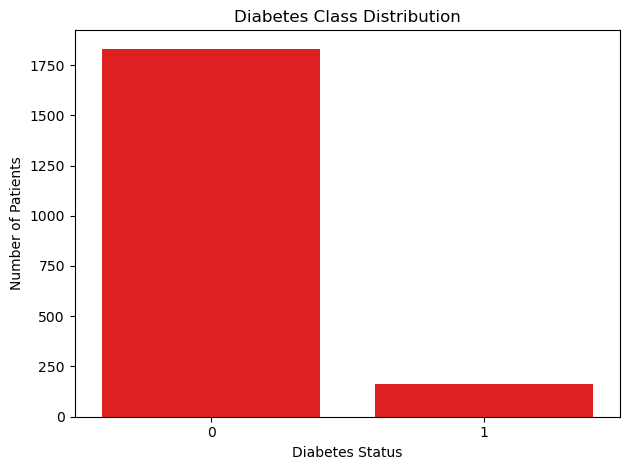

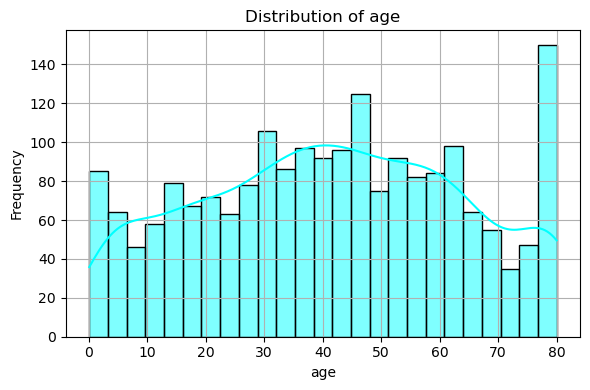

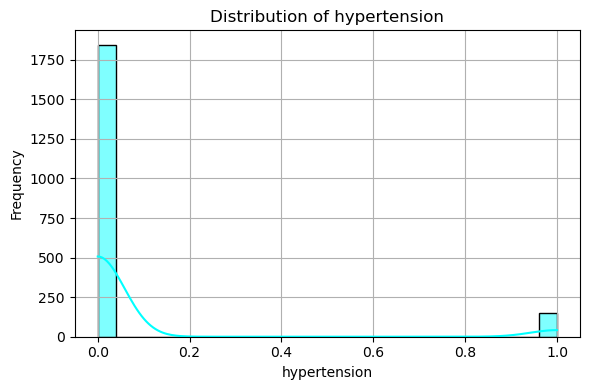

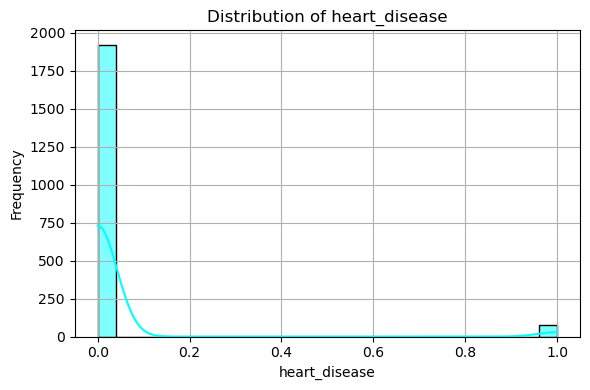

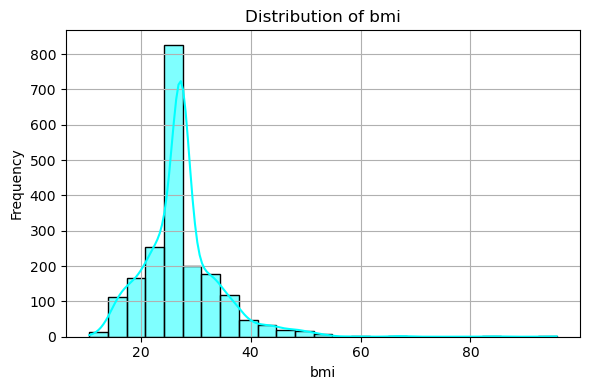

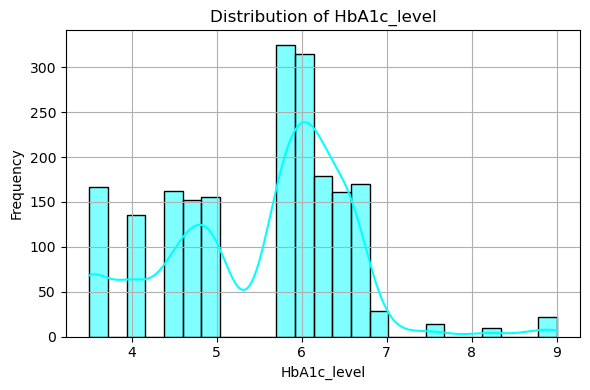

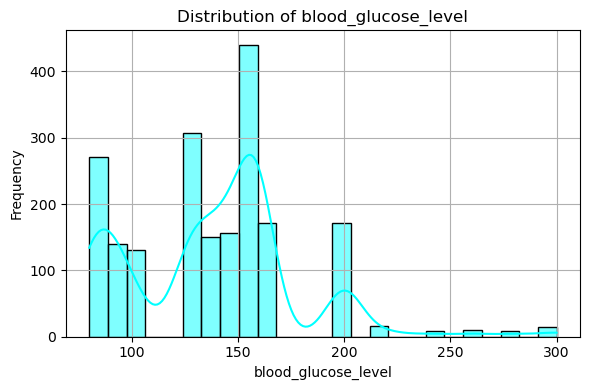

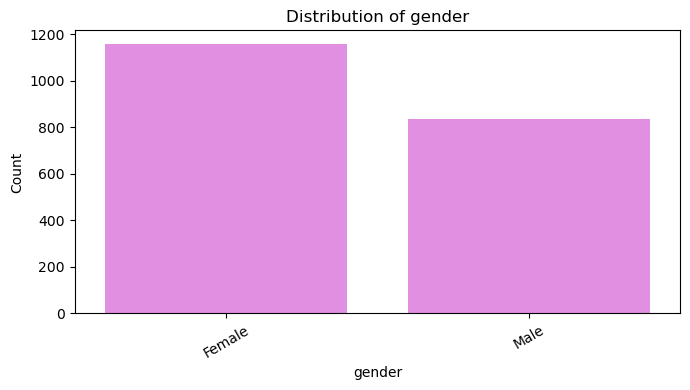

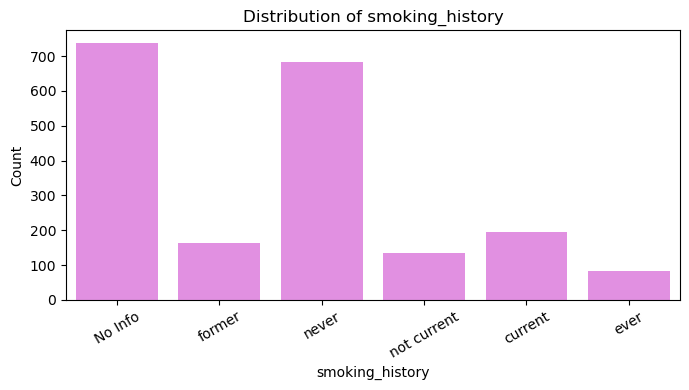

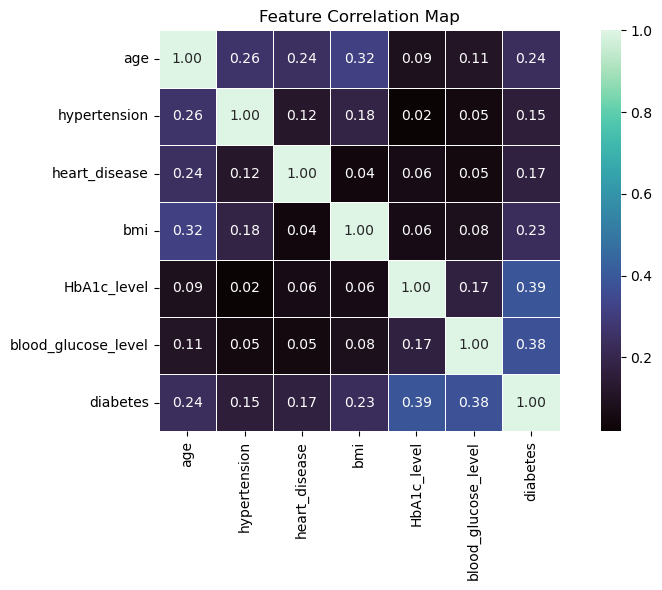

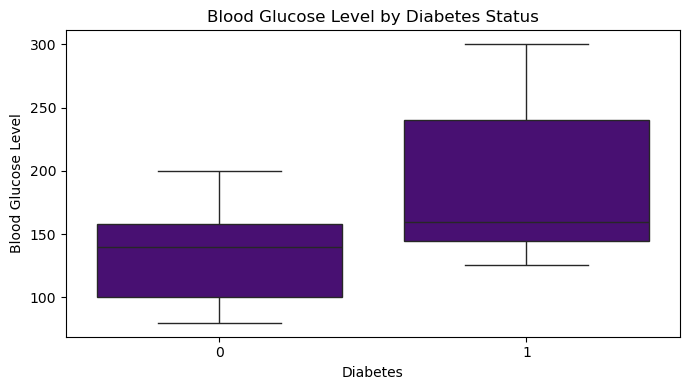

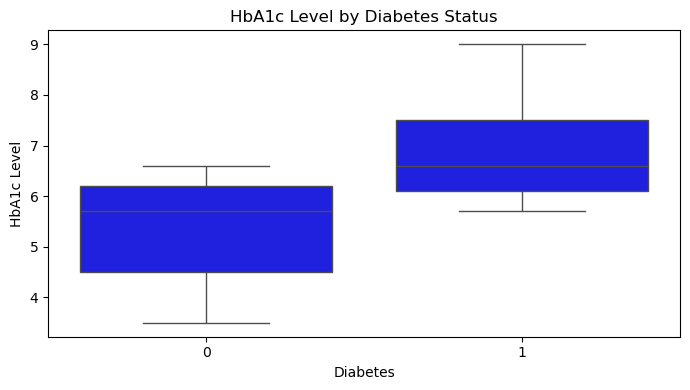

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



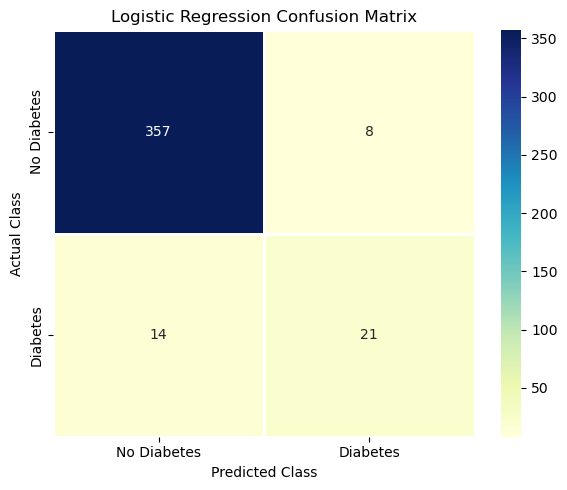

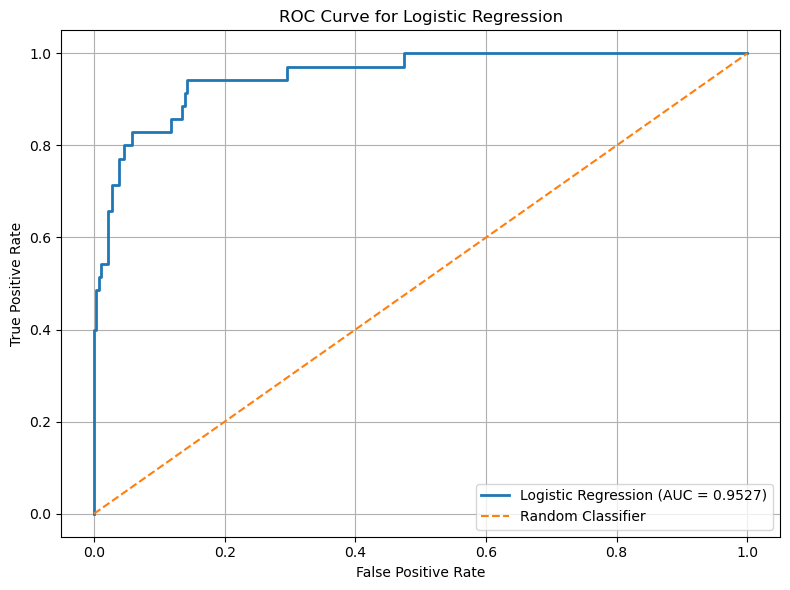

In [18]:
%run "classification1_LR.ipynb"

In [19]:
lr_results={"Accuracy":lr_accuracy,"Precision":lr_precision,"Recall":lr_recall,"Weighted F1":lr_f1,"ROC-AUC":lr_auc}
lr_y_test=y_test.copy()
lr_prob_saved=lr_prob.copy()

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64
Features shape: (1996, 8)
Target shape: (1996,)
Cate

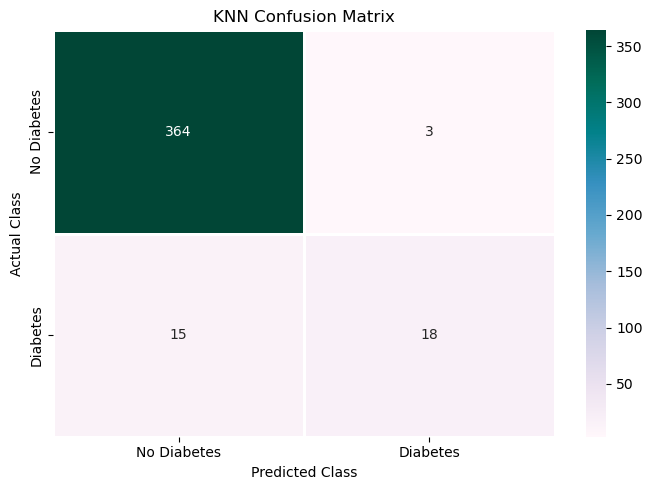

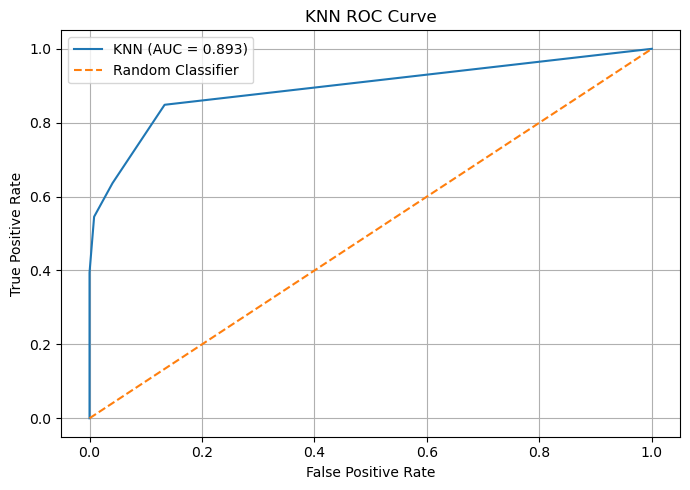

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


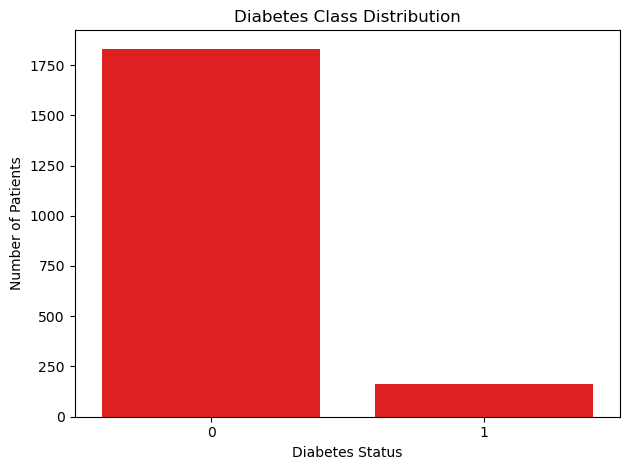

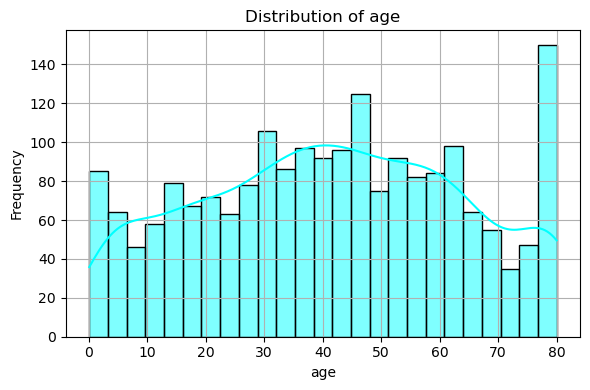

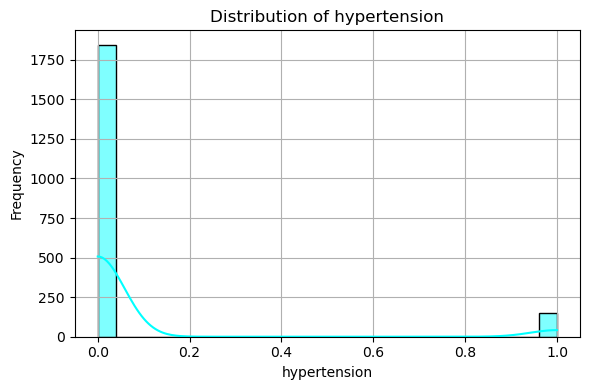

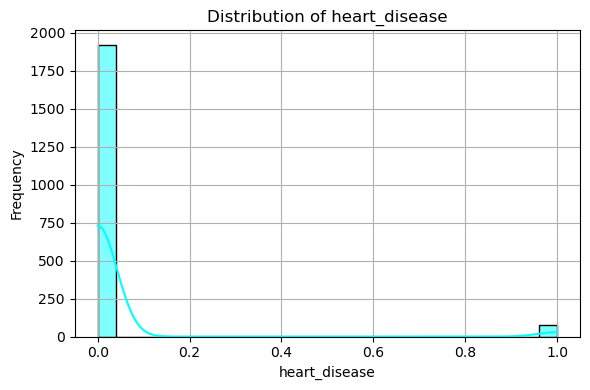

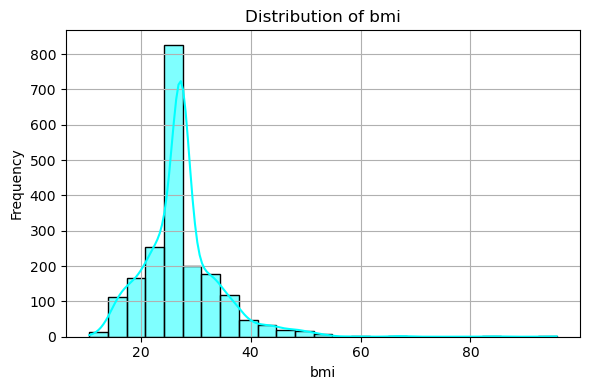

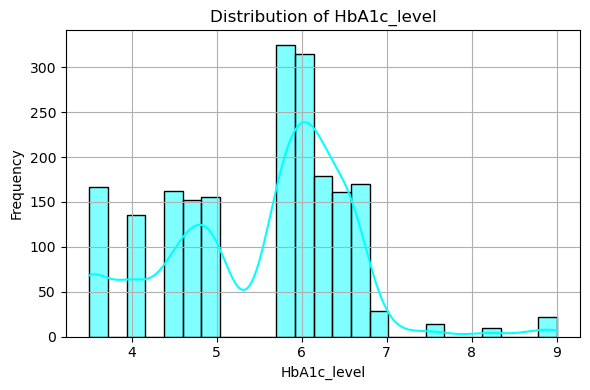

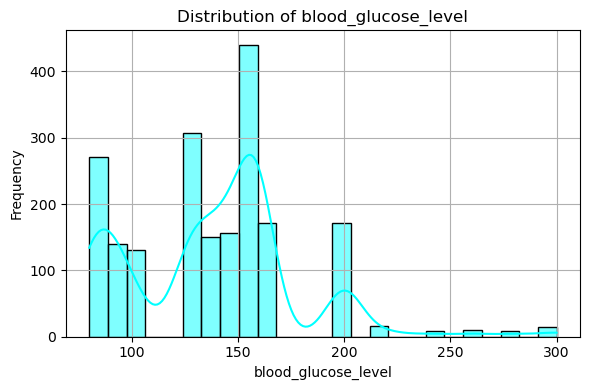

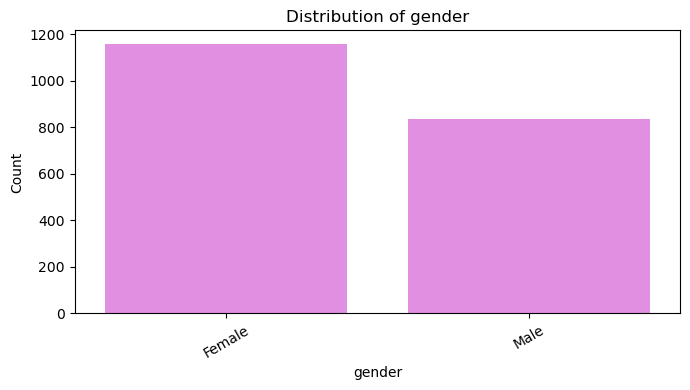

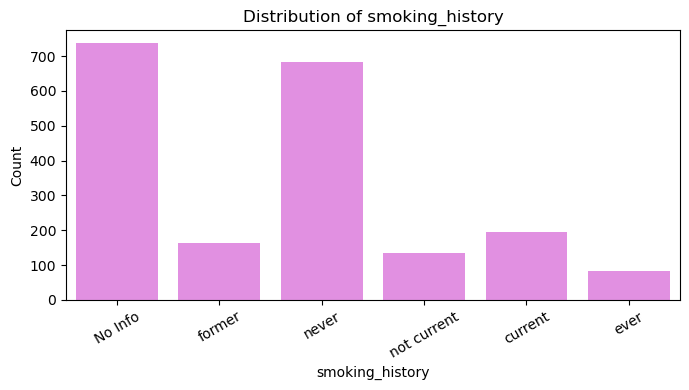

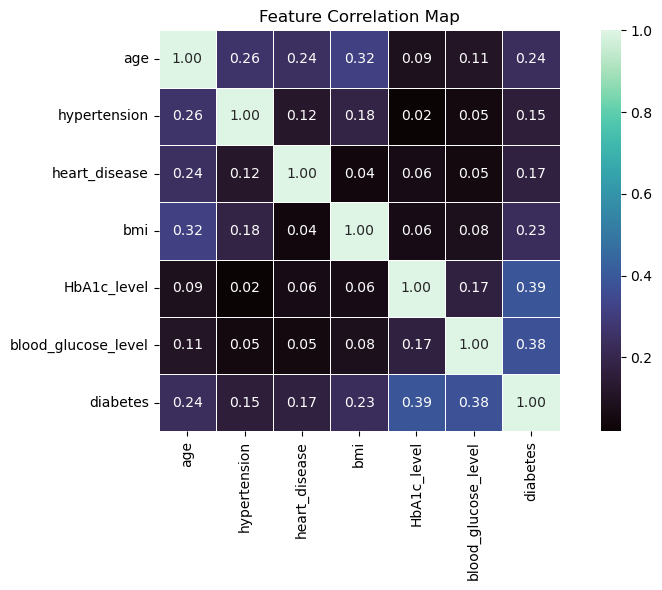

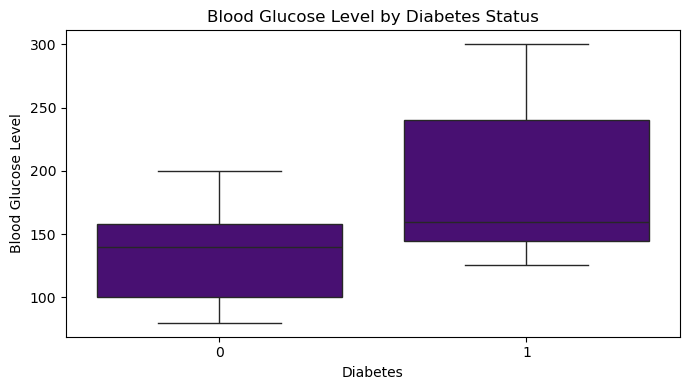

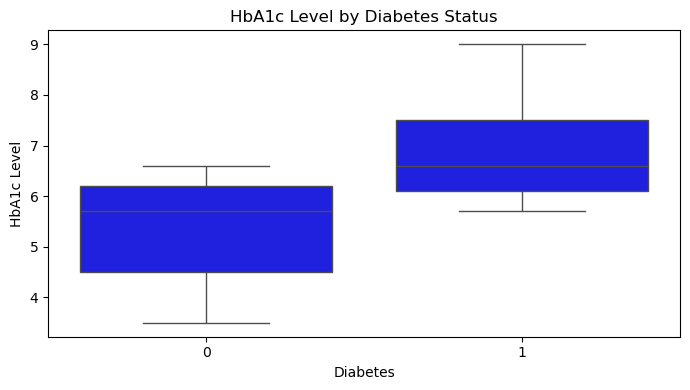

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



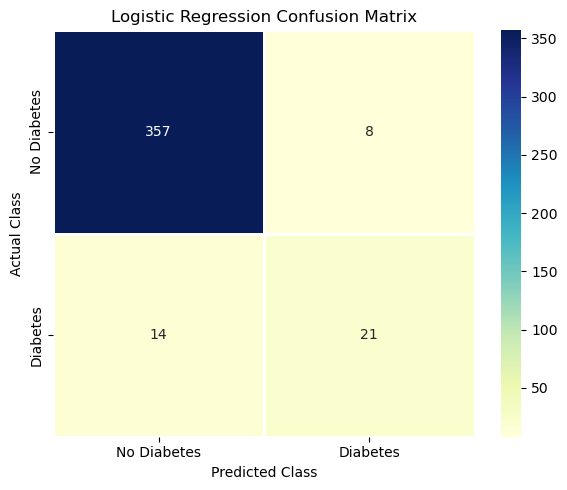

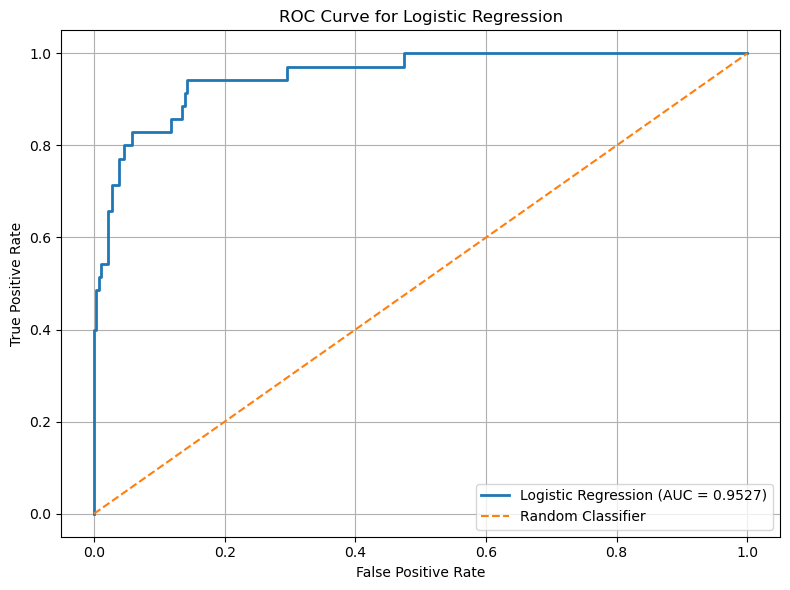

Model comparison


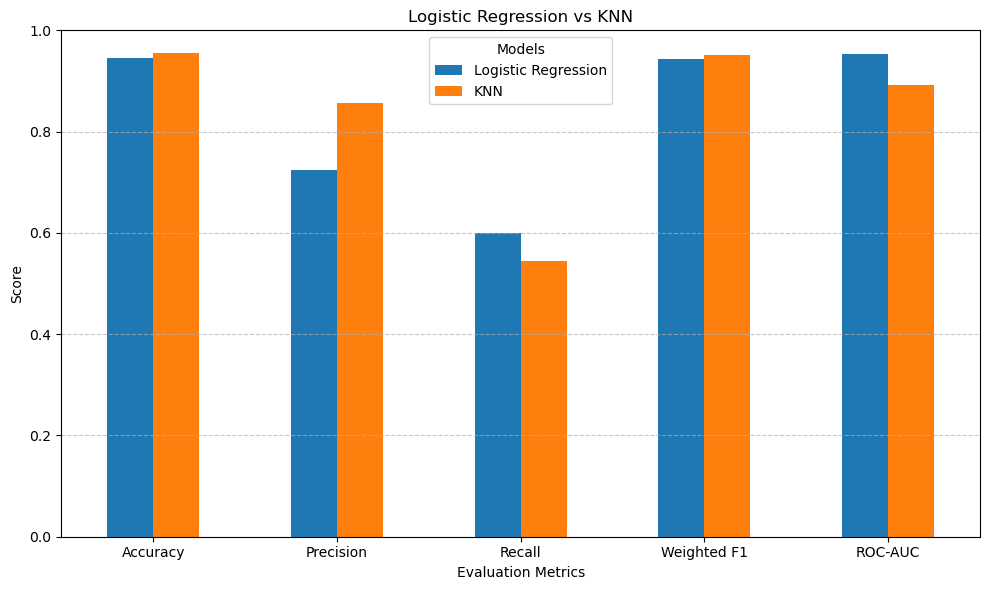

In [20]:
%run "classification2_KNN.ipynb"

In [21]:
knn_results={"Accuracy":knn_accuracy,"Precision":knn_precision,"Recall":knn_recall,"Weighted F1":knn_f1,"ROC-AUC":knn_auc}
knn_y_test=y_test.copy()
knn_prob_saved=knn_prob.copy()


      gender   age  hypertension  heart_disease smoking_history    bmi  \
0     Female  13.0             0              0         No Info  20.82   
1     Female   3.0             0              0         No Info  21.00   
2       Male  63.0             0              0          former  25.32   
3     Female   2.0             0              0           never  17.43   
4     Female  33.0             0              0     not current  40.08   
...      ...   ...           ...            ...             ...    ...   
1995  Female  24.0             0              0         No Info  23.89   
1996  Female  46.0             0              0         No Info  32.89   
1997    Male  15.0             0              0         current  20.88   
1998  Female  47.0             0              0           never  24.59   
1999    Male  69.0             1              1           never  27.32   

      HbA1c_level  blood_glucose_level  
0             5.8                  126  
1             5.0            

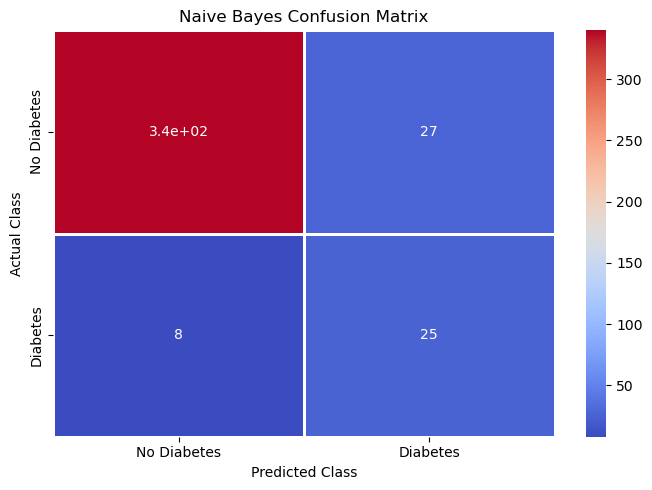

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64
Features shape: (1996, 8)
Target shape: (1996,)
Cate

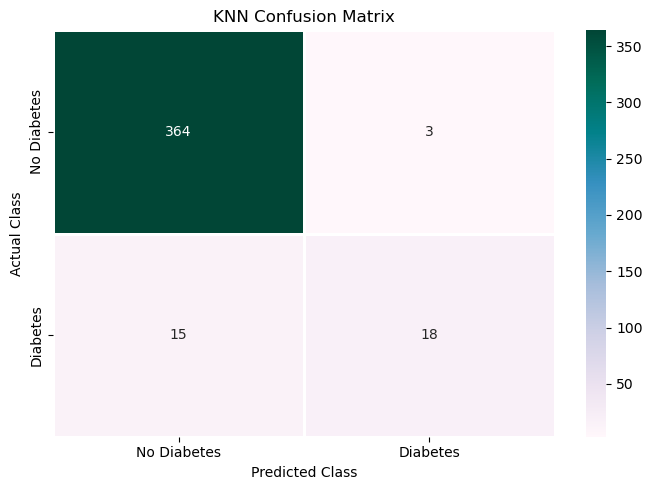

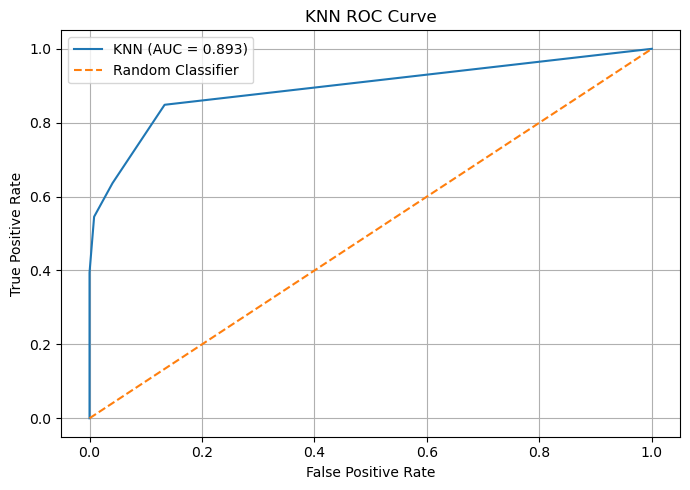

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


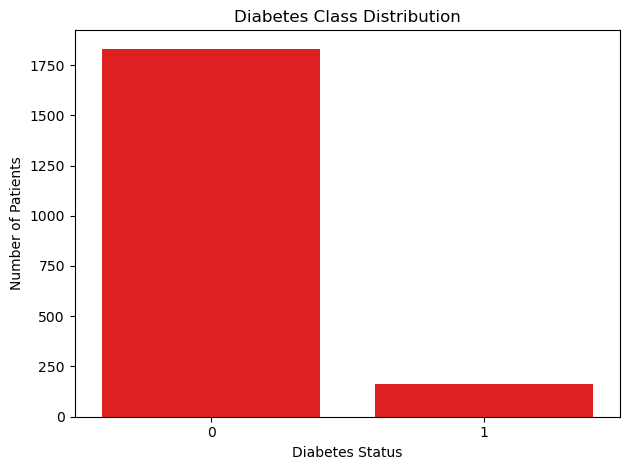

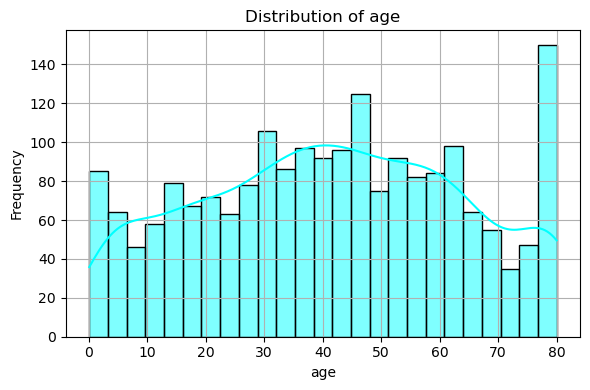

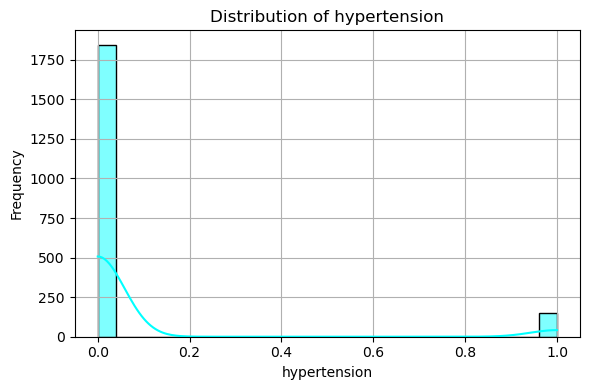

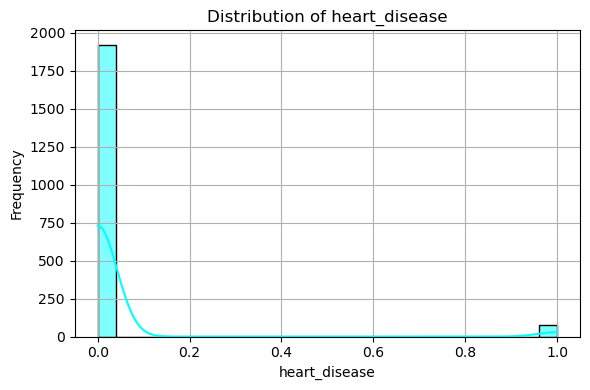

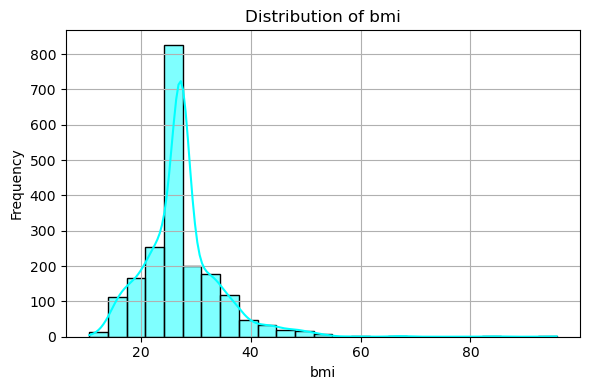

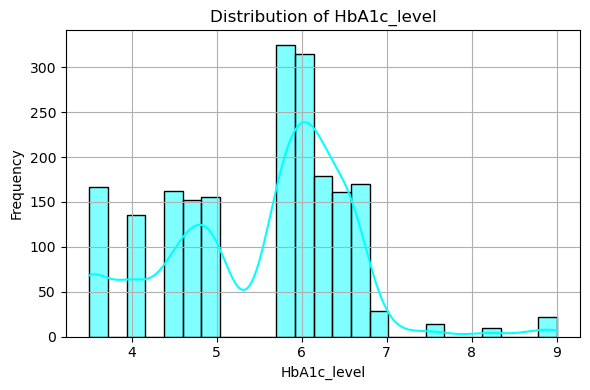

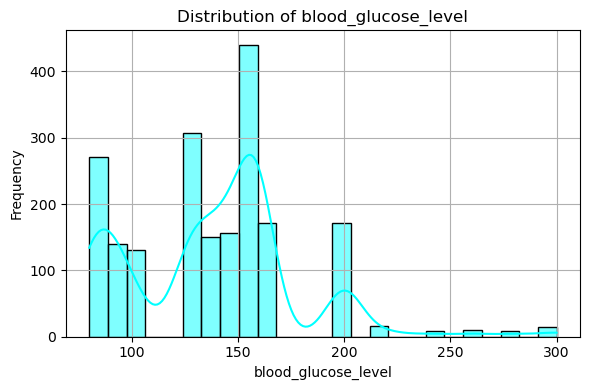

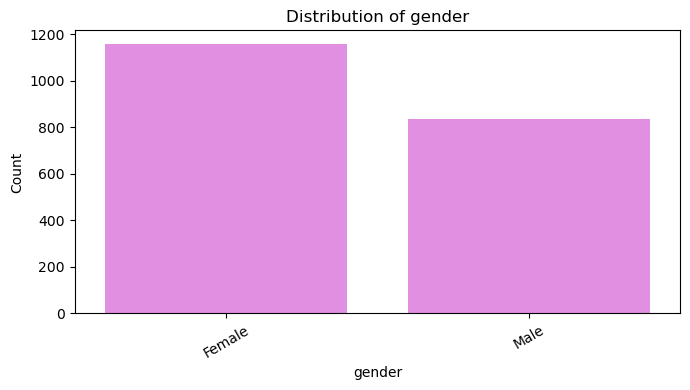

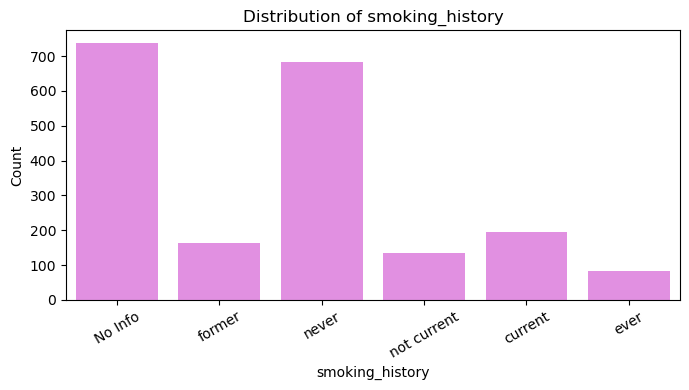

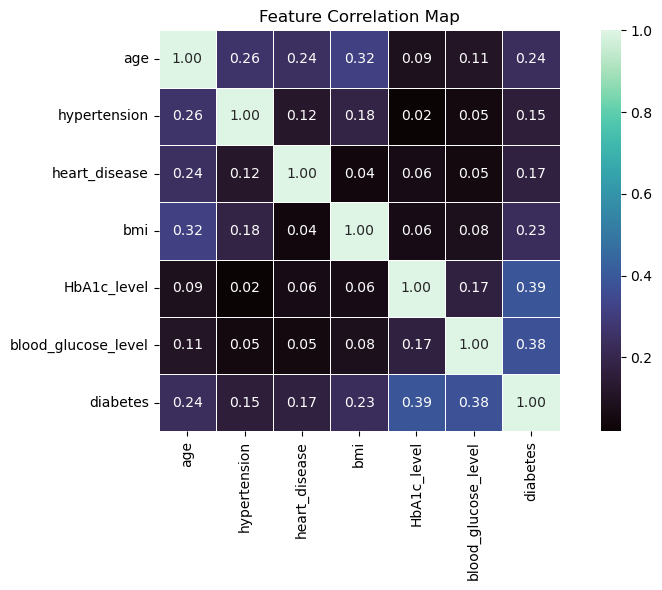

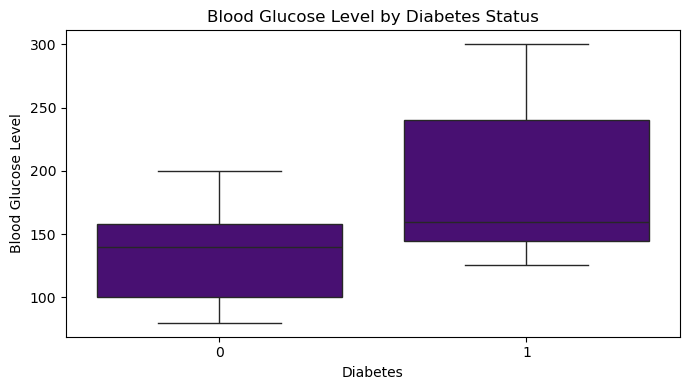

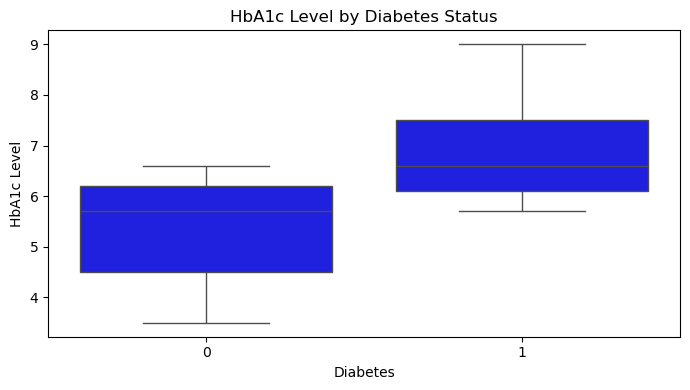

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



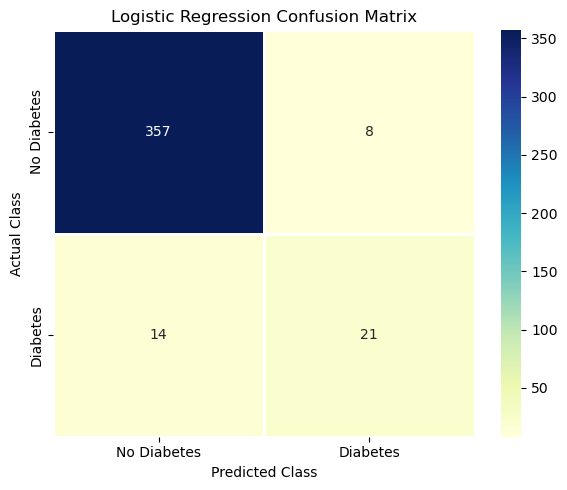

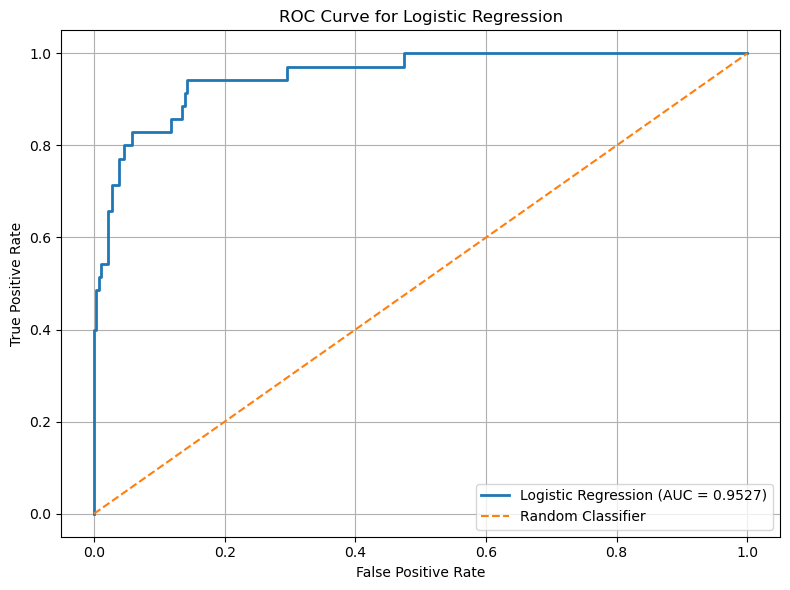

Model comparison


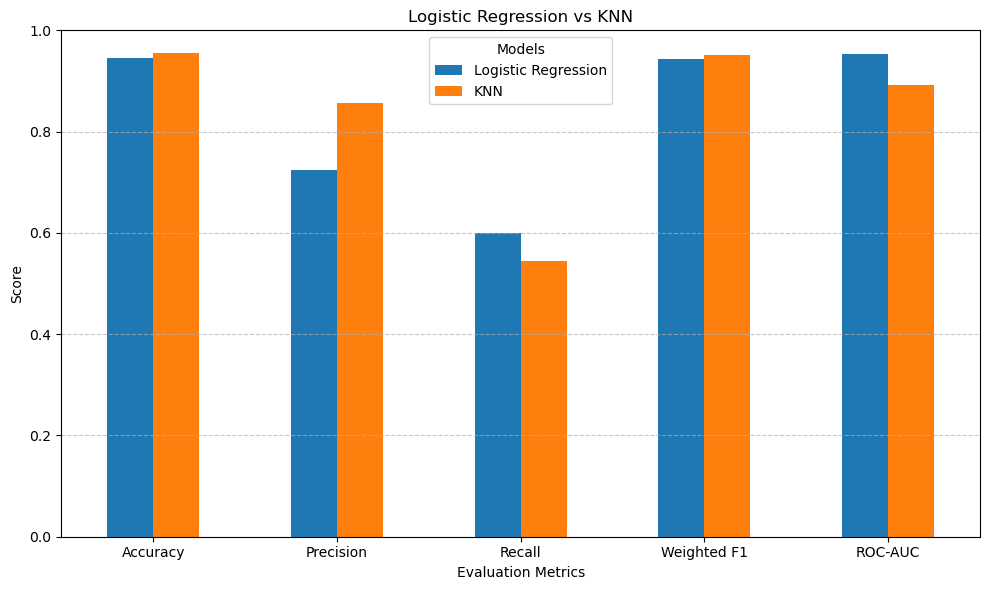

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


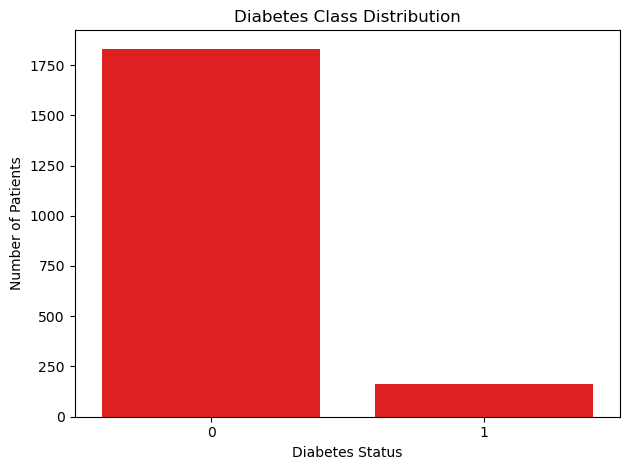

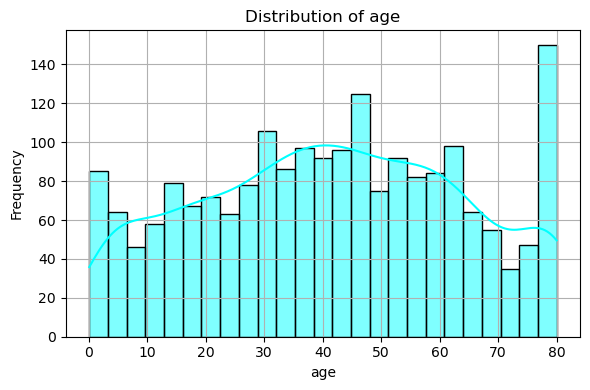

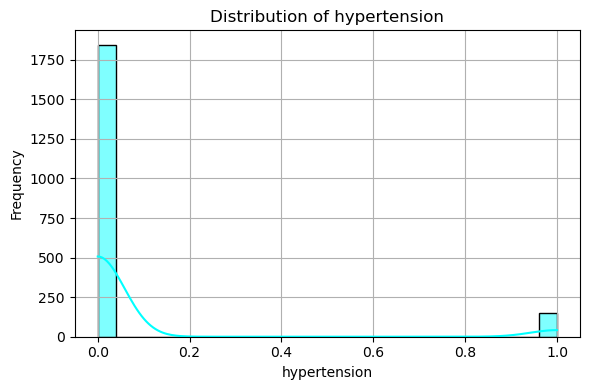

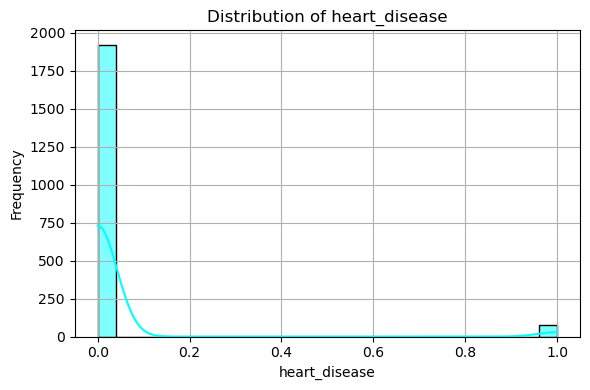

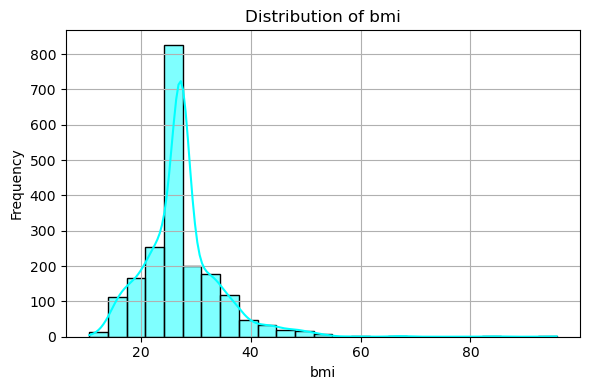

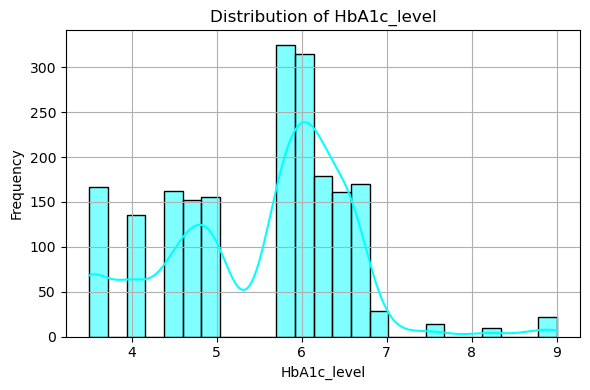

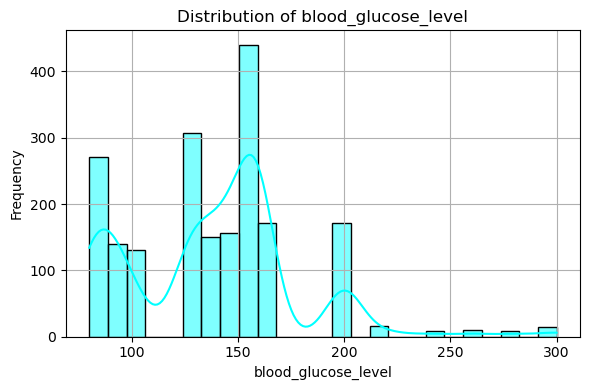

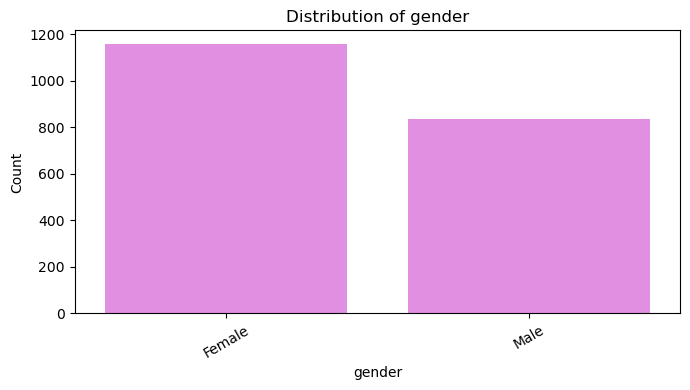

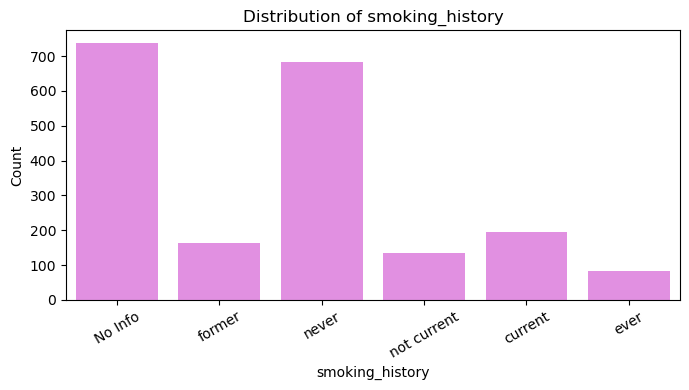

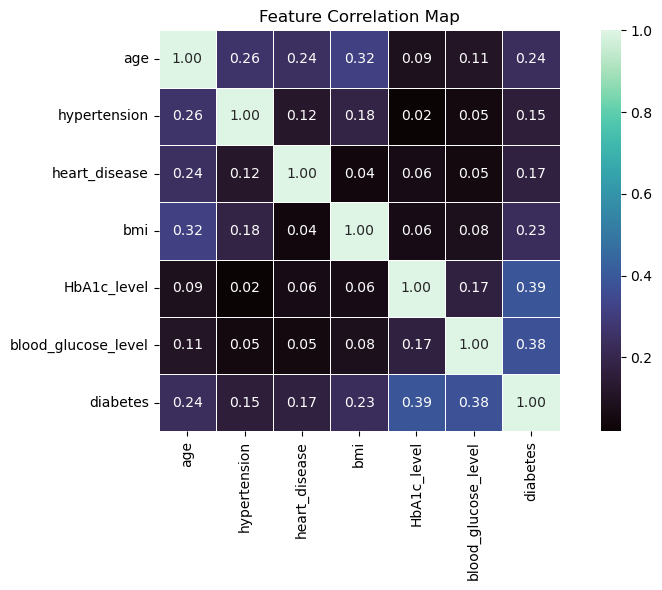

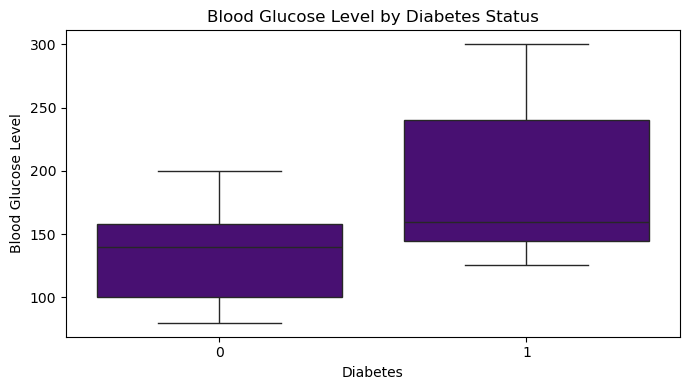

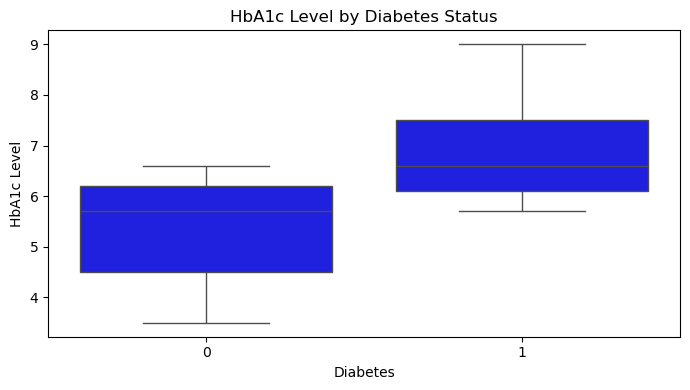

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



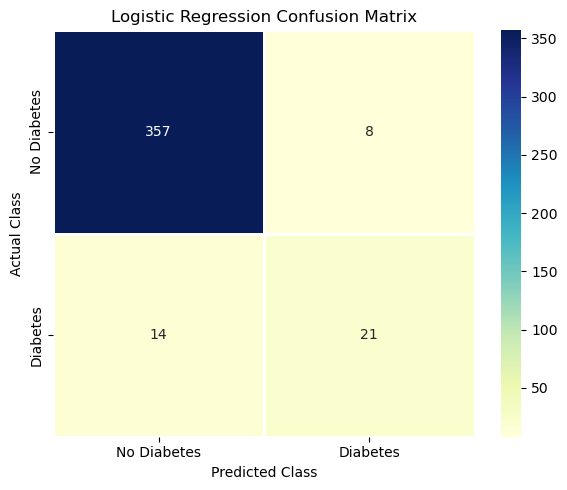

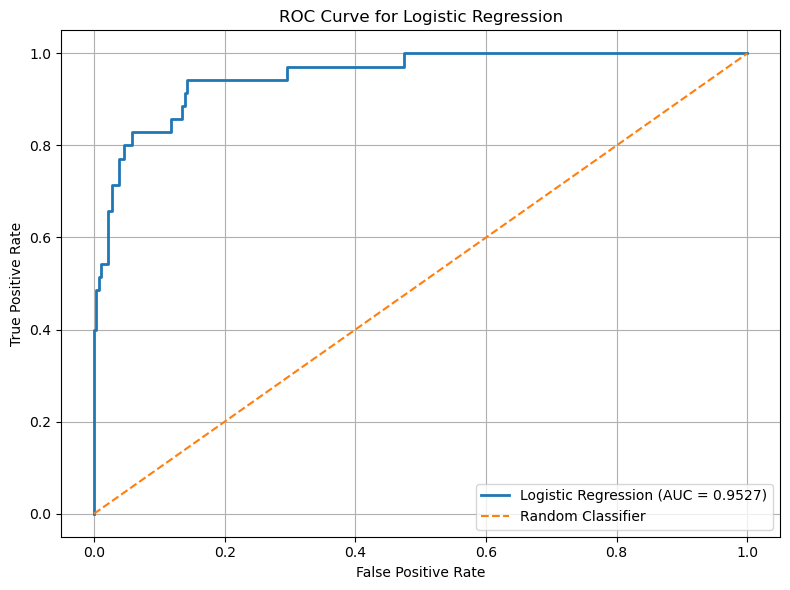

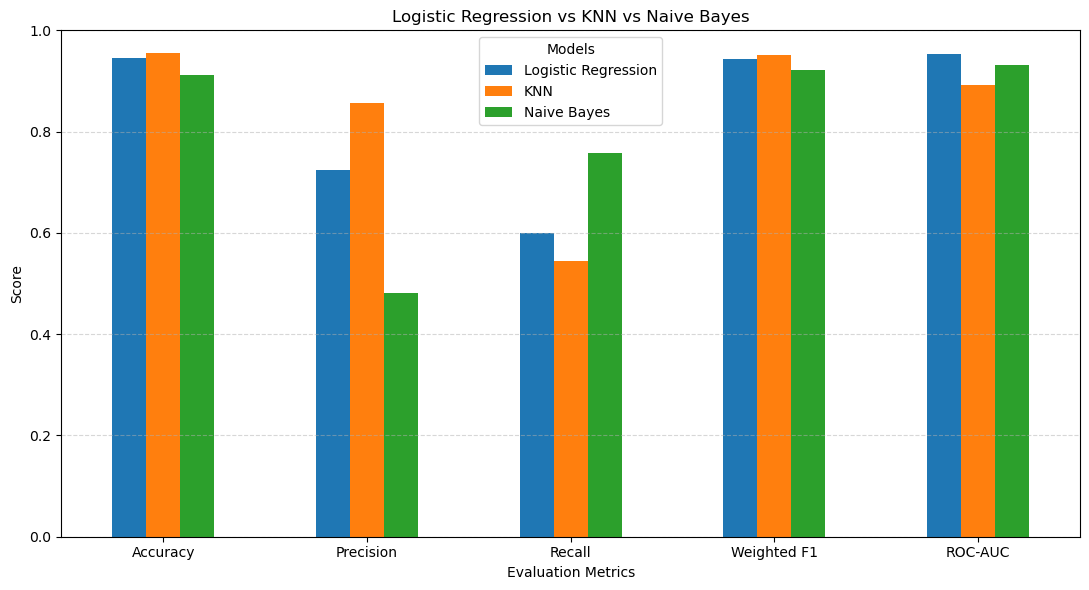

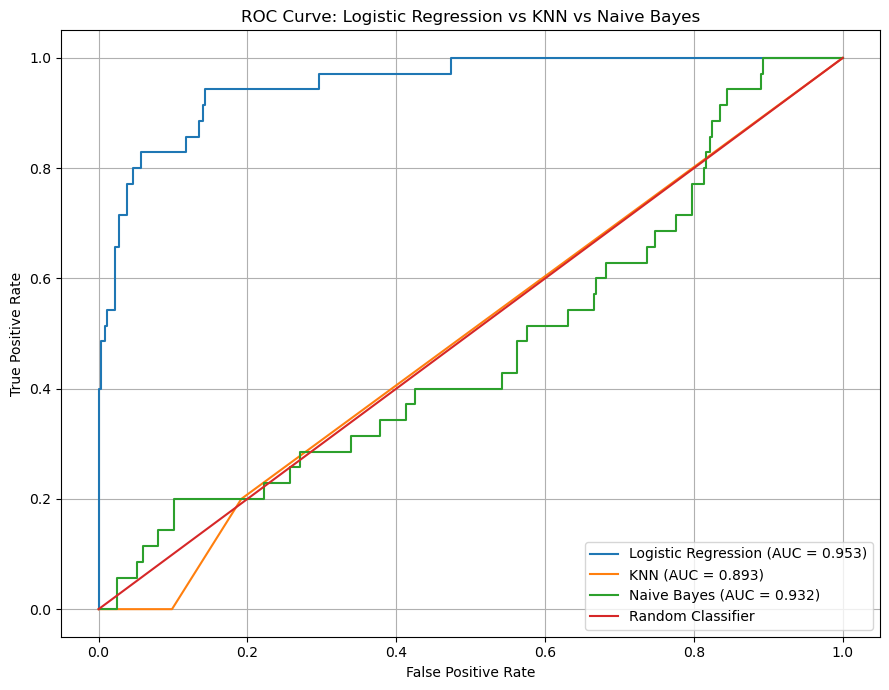

In [22]:
%run "classification3_GNB.ipynb"

In [23]:
nb_results={"Accuracy":nb_accuracy,"Precision":nb_precision,"Recall":nb_recall,"Weighted F1":nb_f1,"ROC-AUC":nb_auc}
nb_y_test=y_test.copy()
nb_prob_saved=nb_prob.copy()

Dataset shape: (2000, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               2000 non-null   object 
 1   age                  2000 non-null   float64
 2   hypertension         2000 non-null   int64  
 3   heart_disease        2000 non-null   int64  
 4   smoking_history      2000 non-null   object 
 5   bmi                  2000 non-null   float64
 6   HbA1c_level          2000 non-null   float64
 7   blood_glucose_level  2000 non-null   int64  
 8   diabetes             2000 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 140.8+ KB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes   

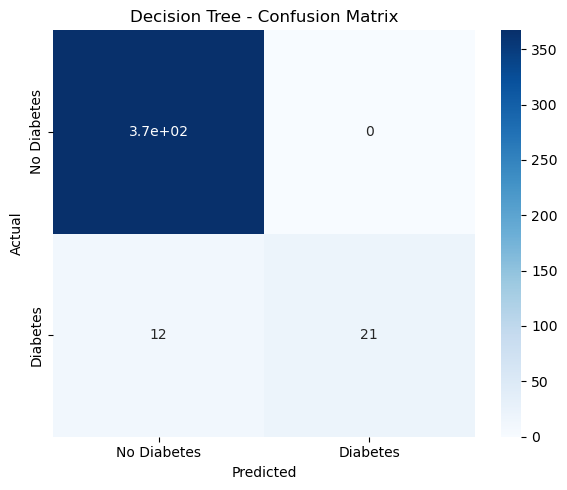

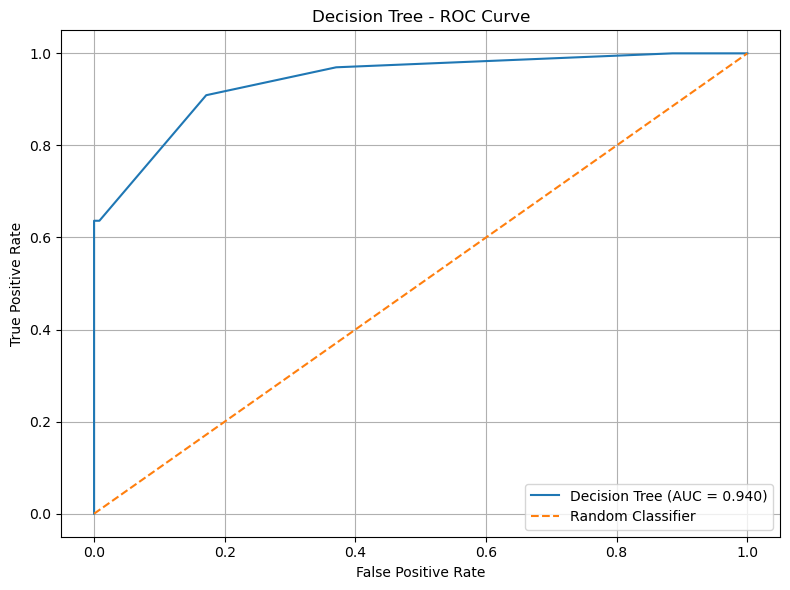

                                     Feature  Importance
12                    remainder__HbA1c_level    0.676039
13            remainder__blood_glucose_level    0.287950
11                            remainder__bmi    0.021389
8                             remainder__age    0.014622
0                 categorical__gender_Female    0.000000
1                   categorical__gender_Male    0.000000
2       categorical__smoking_history_No Info    0.000000
3       categorical__smoking_history_current    0.000000
4          categorical__smoking_history_ever    0.000000
5        categorical__smoking_history_former    0.000000
6         categorical__smoking_history_never    0.000000
7   categorical__smoking_history_not current    0.000000
9                    remainder__hypertension    0.000000
10                  remainder__heart_disease    0.000000


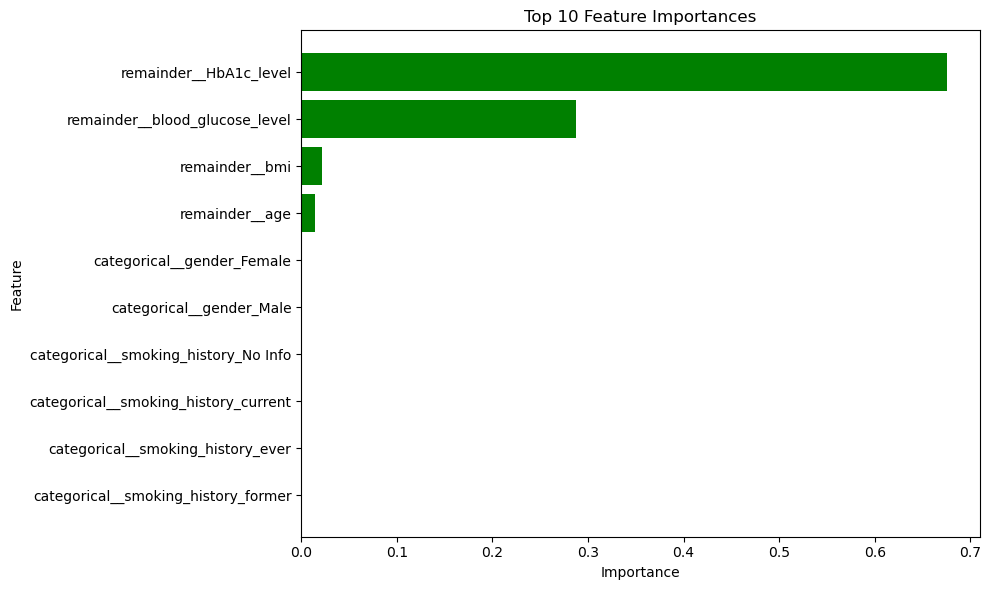

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


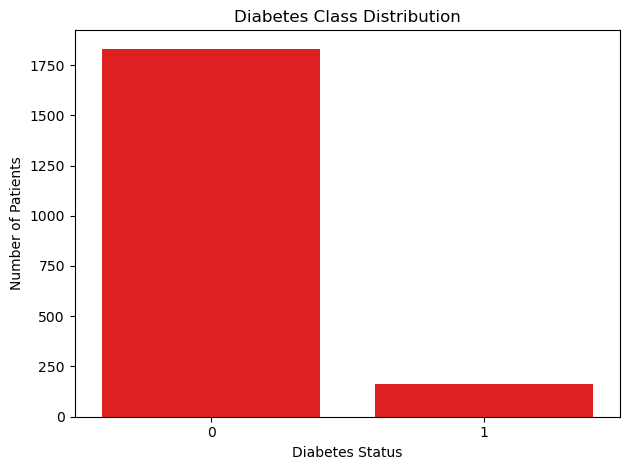

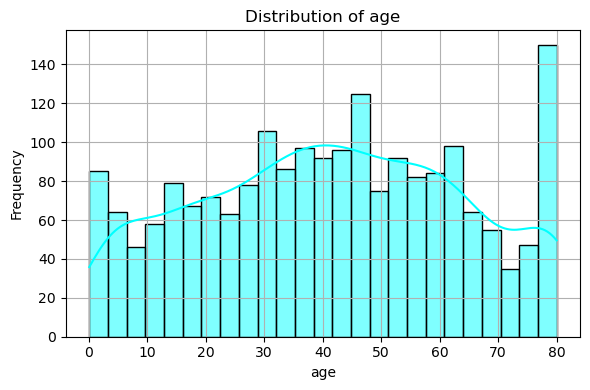

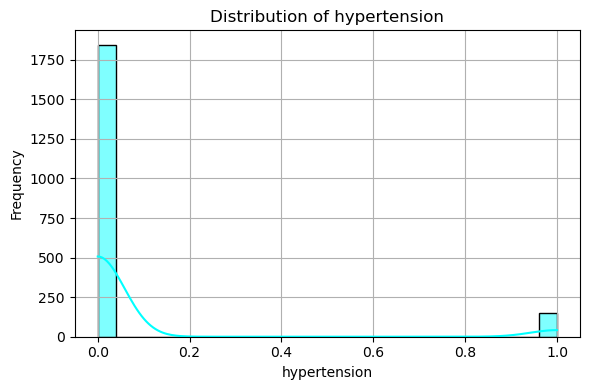

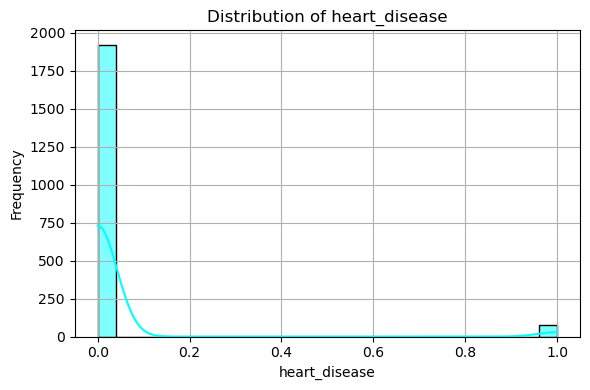

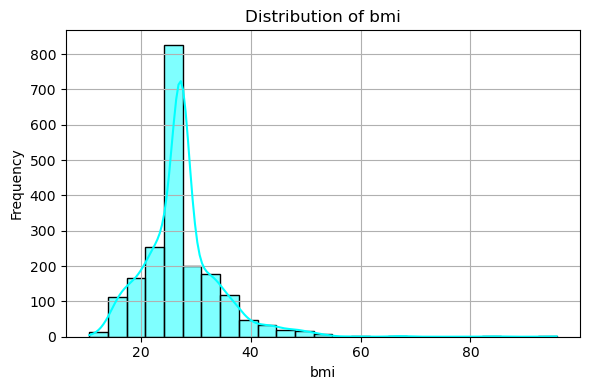

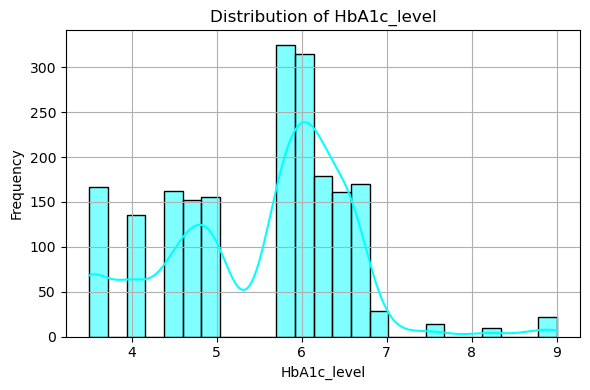

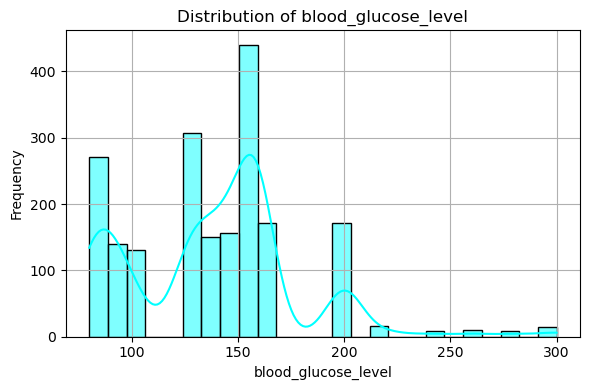

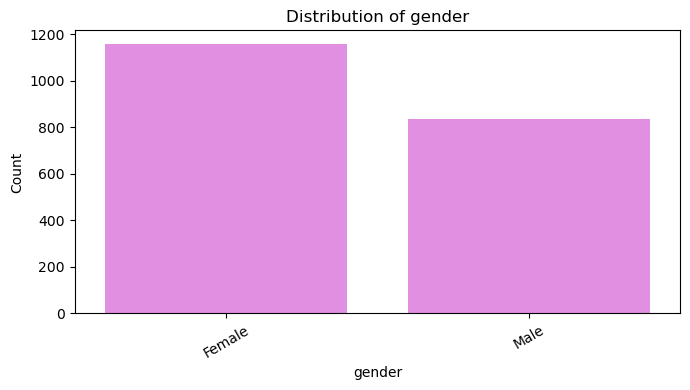

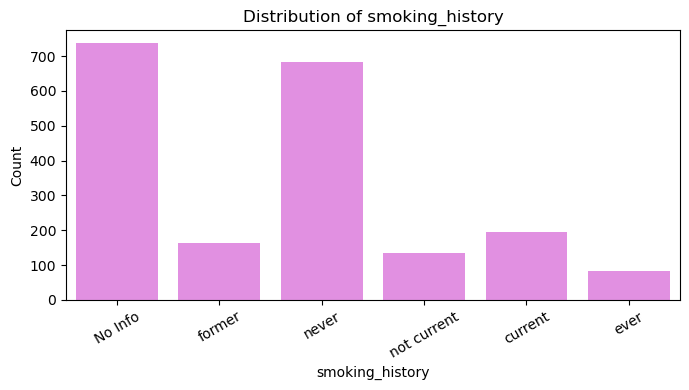

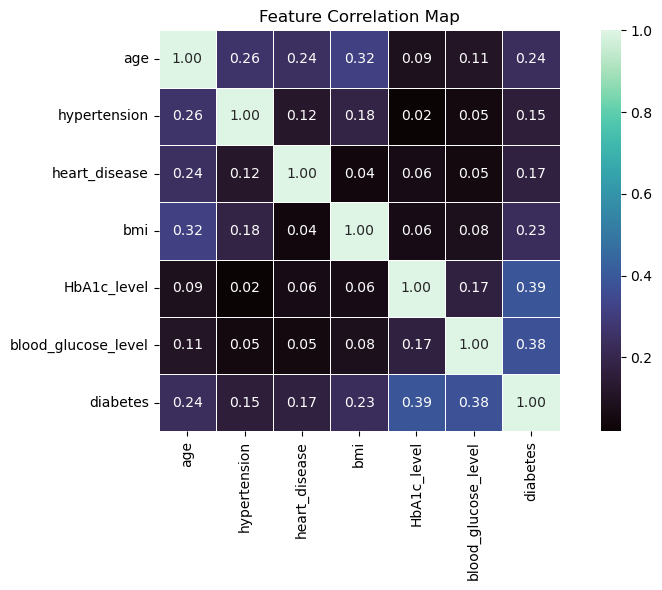

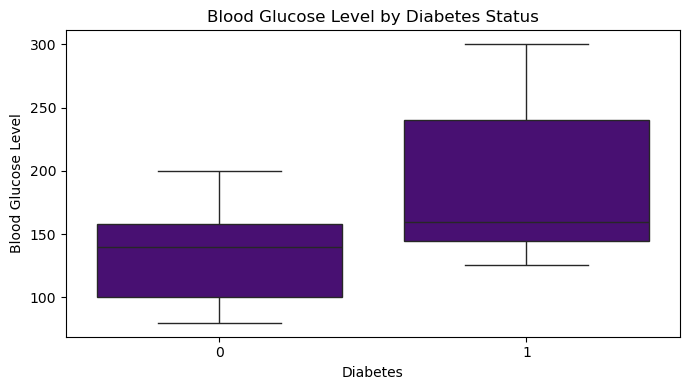

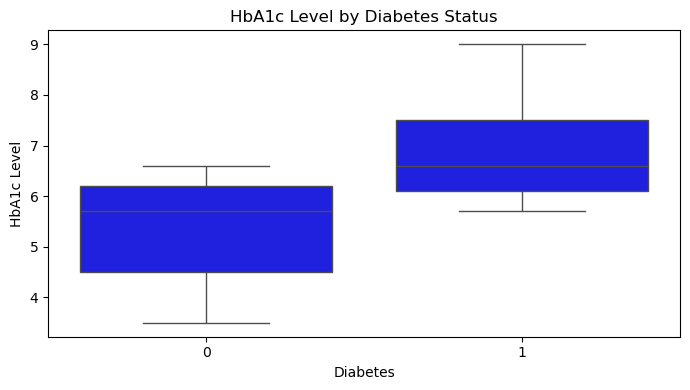

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



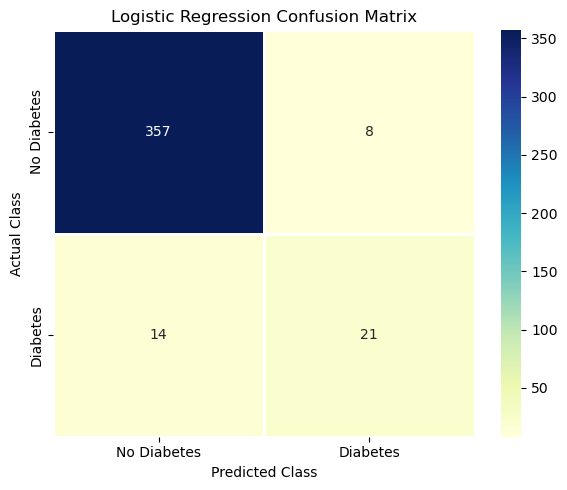

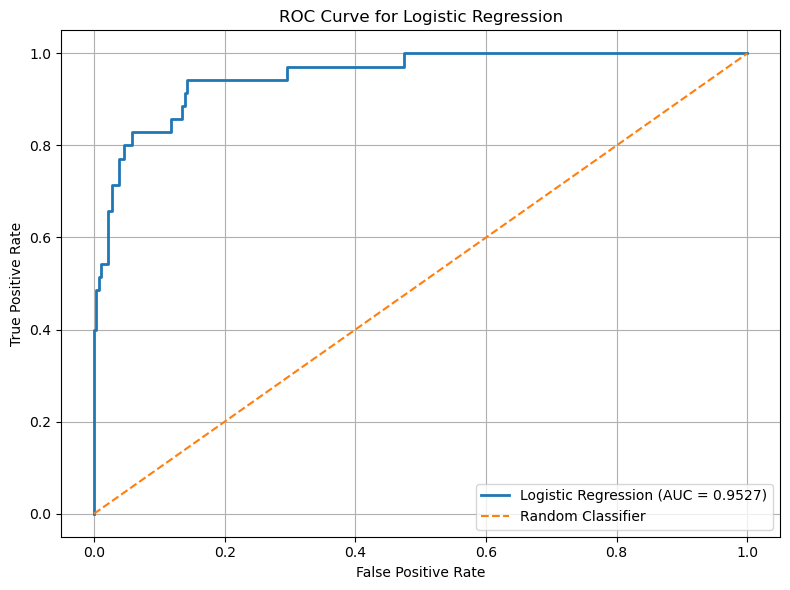

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64
Features shape: (1996, 8)
Target shape: (1996,)
Cate

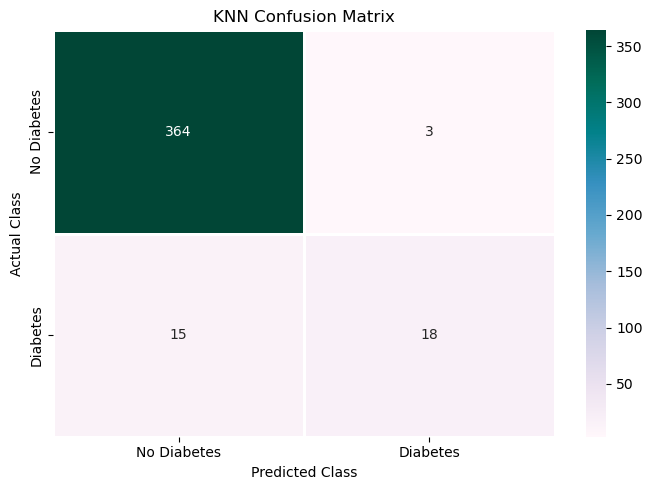

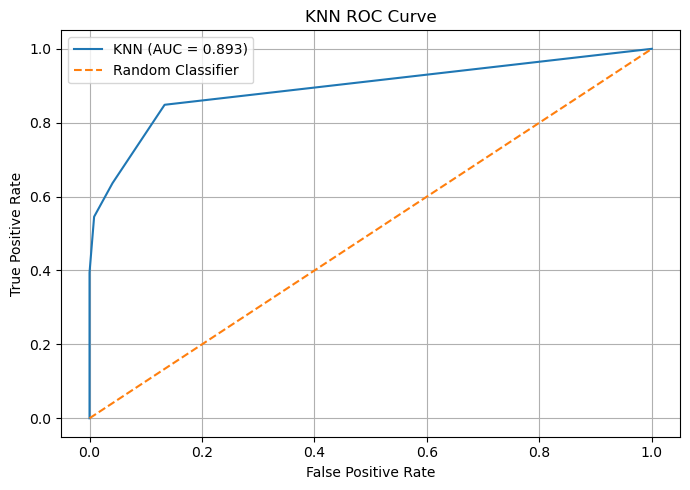

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


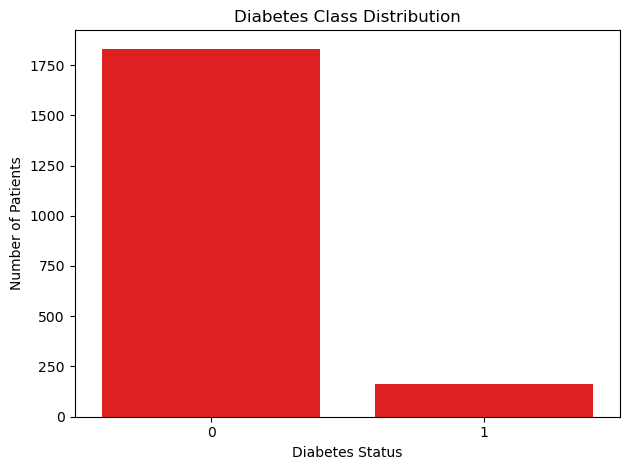

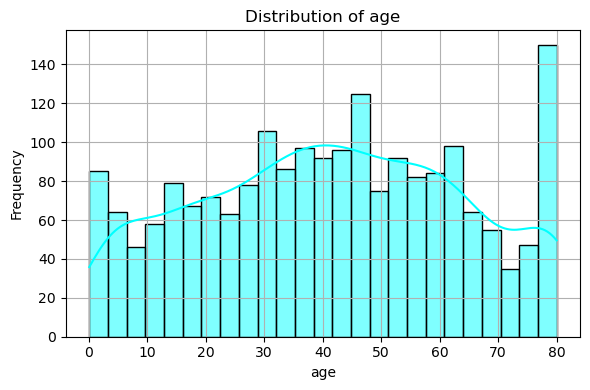

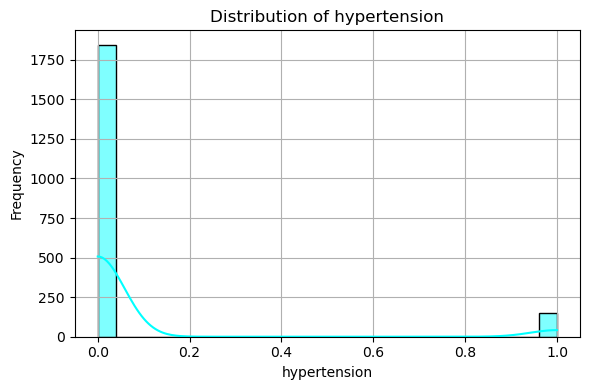

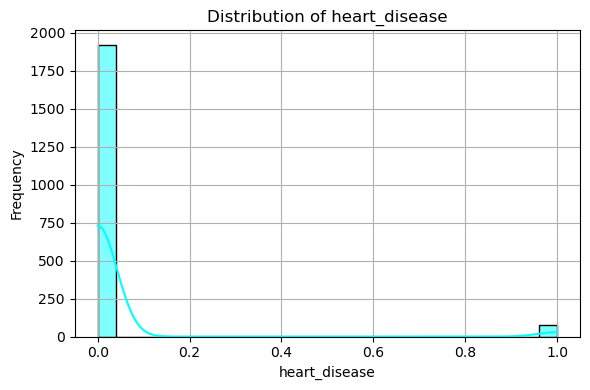

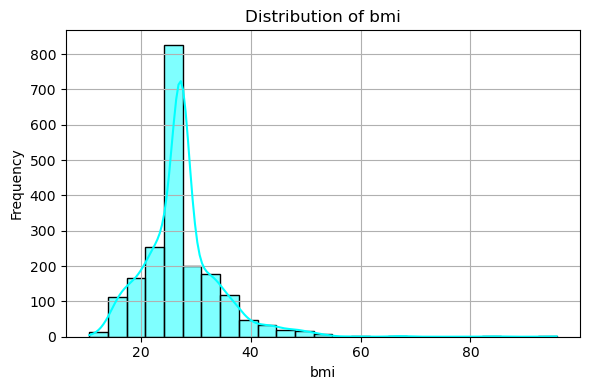

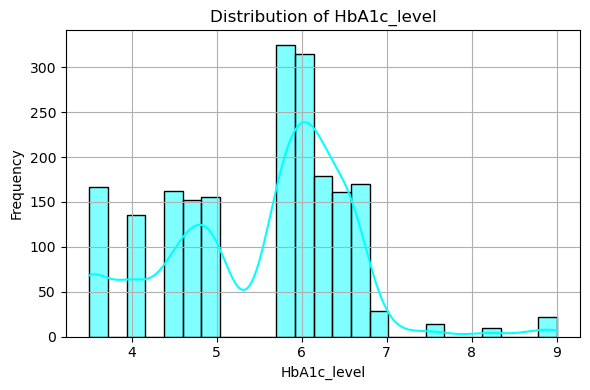

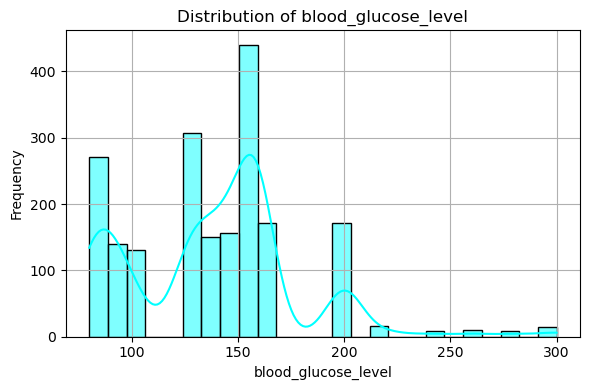

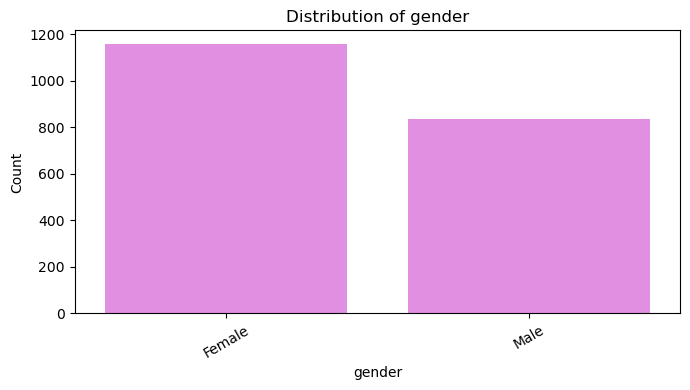

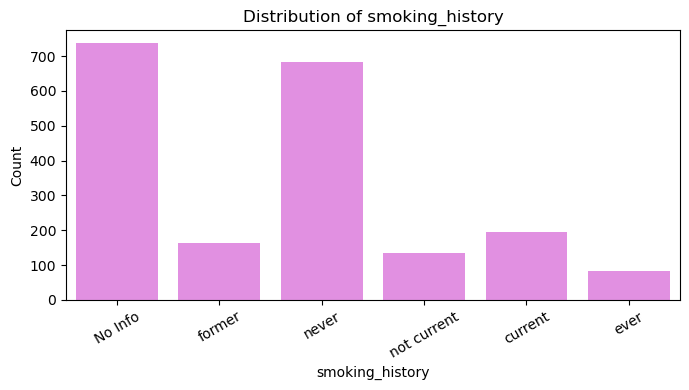

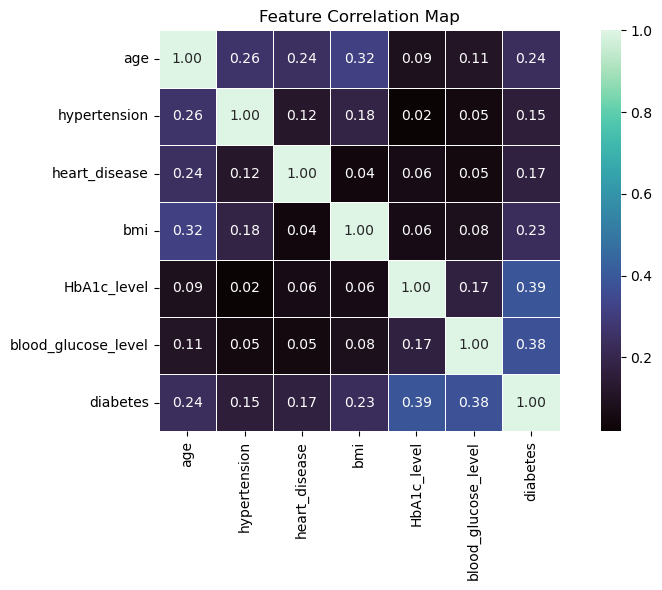

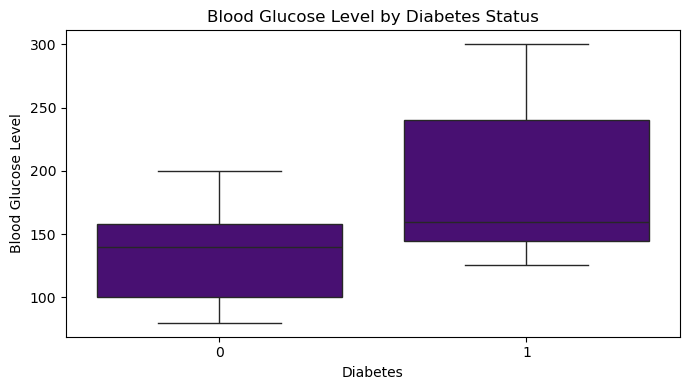

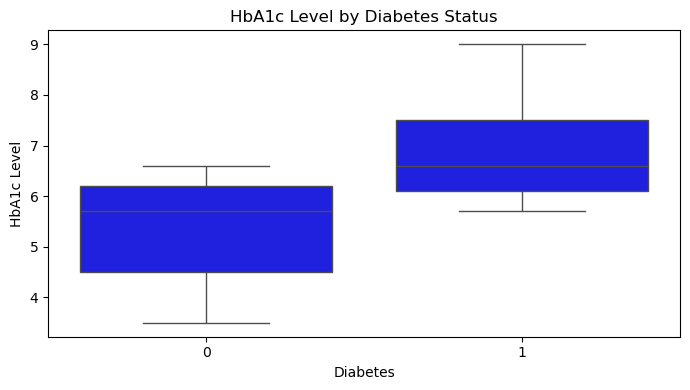

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



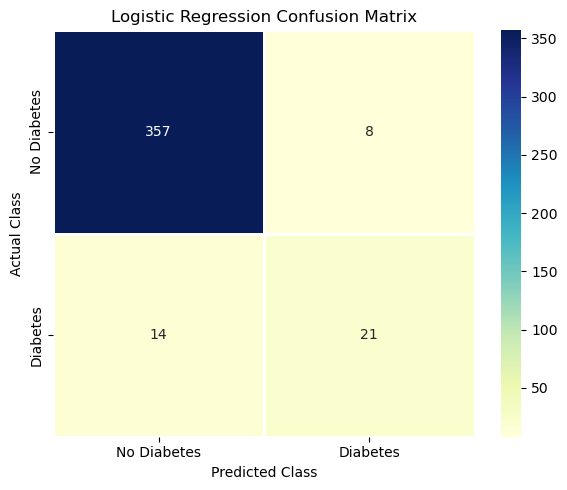

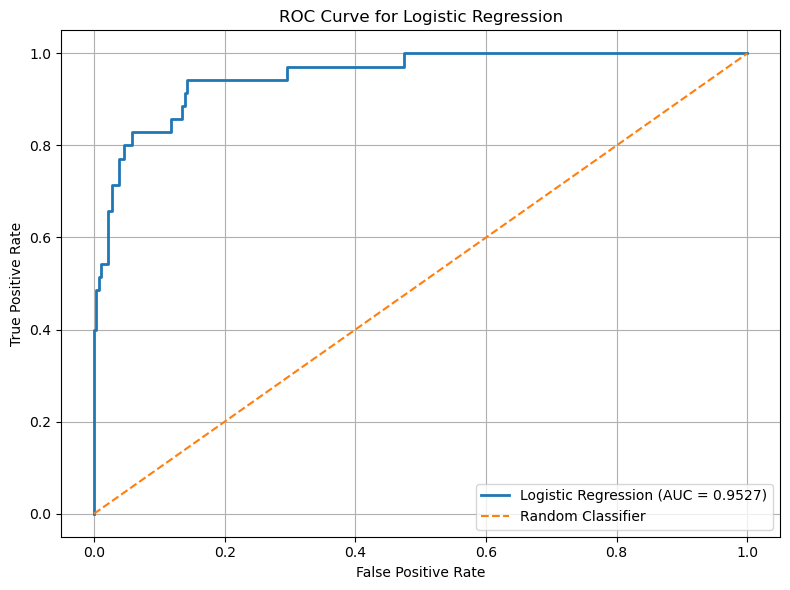

Model comparison


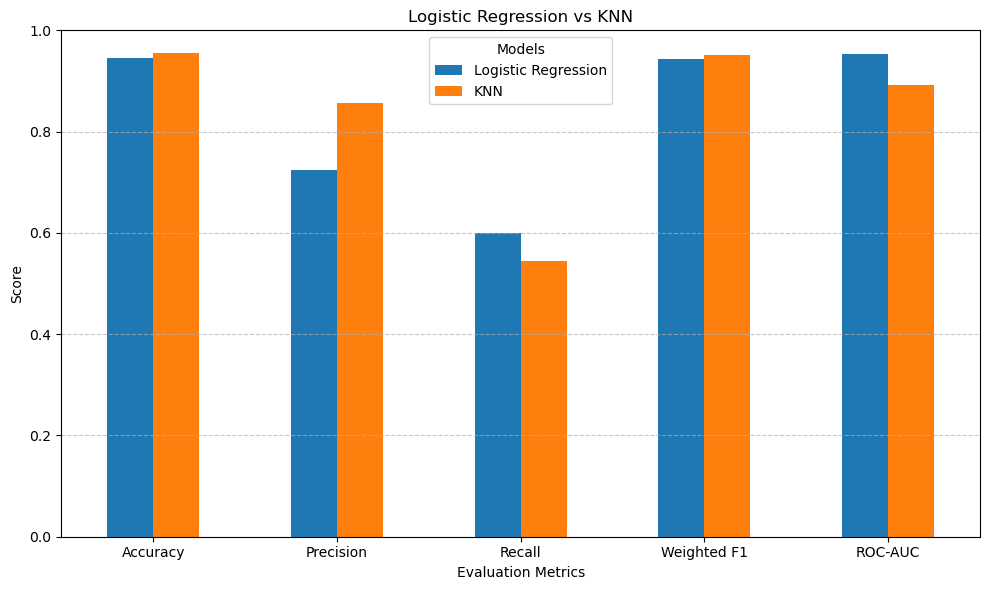

      gender   age  hypertension  heart_disease smoking_history    bmi  \
0     Female  13.0             0              0         No Info  20.82   
1     Female   3.0             0              0         No Info  21.00   
2       Male  63.0             0              0          former  25.32   
3     Female   2.0             0              0           never  17.43   
4     Female  33.0             0              0     not current  40.08   
...      ...   ...           ...            ...             ...    ...   
1995  Female  24.0             0              0         No Info  23.89   
1996  Female  46.0             0              0         No Info  32.89   
1997    Male  15.0             0              0         current  20.88   
1998  Female  47.0             0              0           never  24.59   
1999    Male  69.0             1              1           never  27.32   

      HbA1c_level  blood_glucose_level  
0             5.8                  126  
1             5.0            

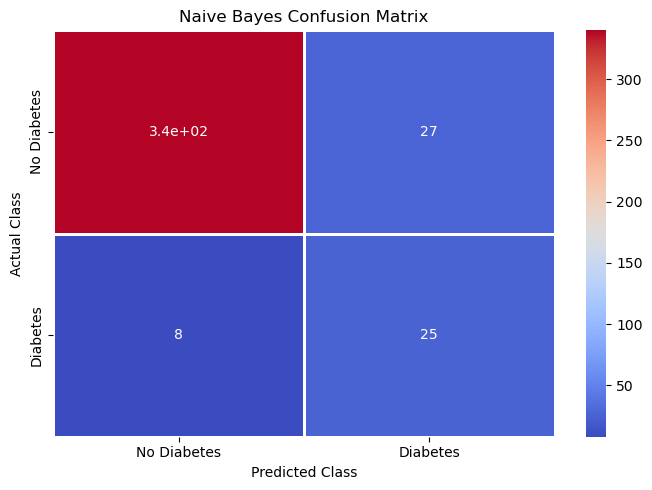

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64
Features shape: (1996, 8)
Target shape: (1996,)
Cate

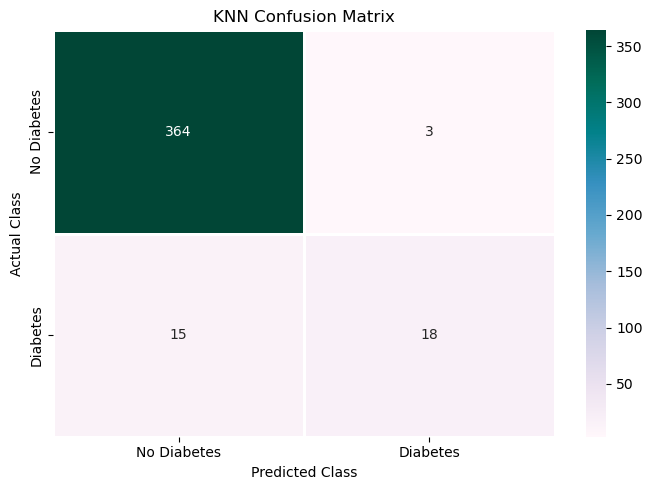

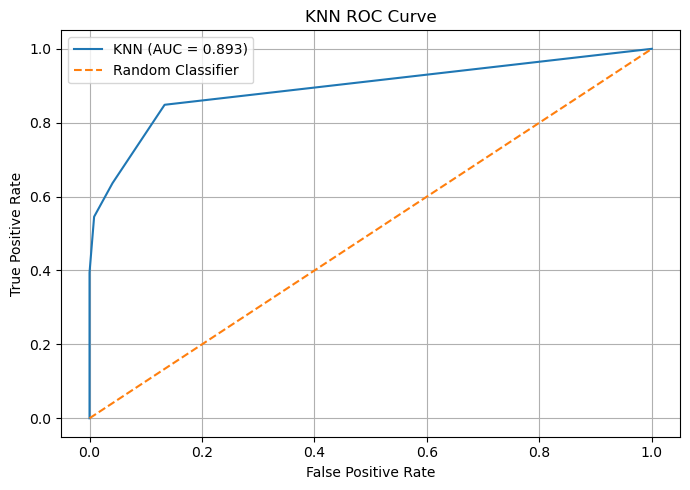

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


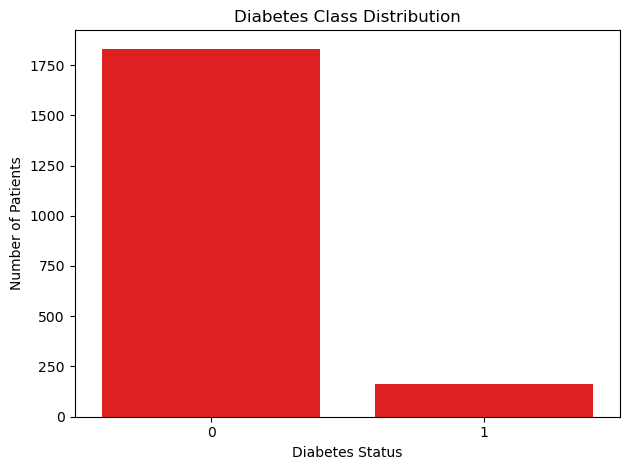

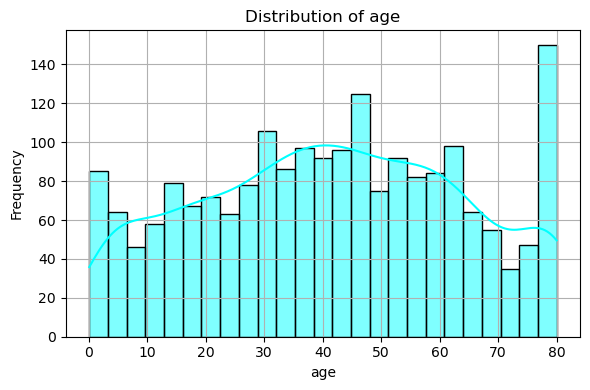

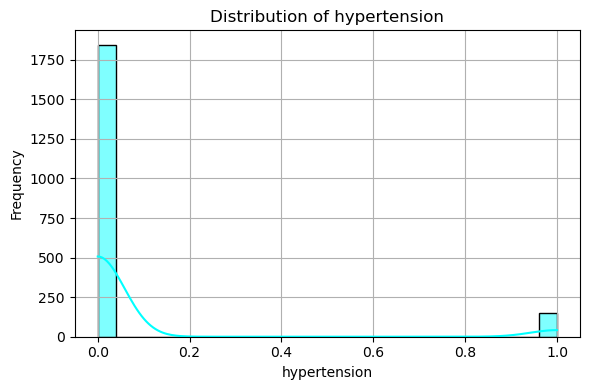

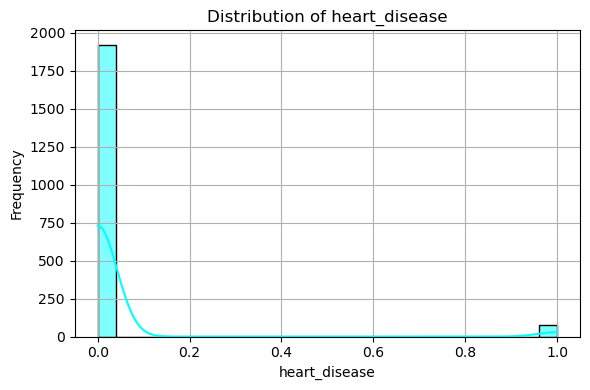

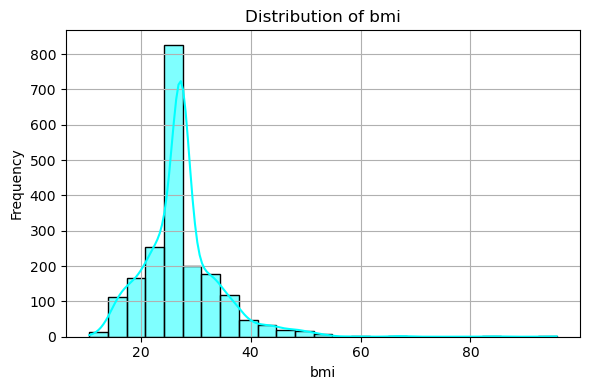

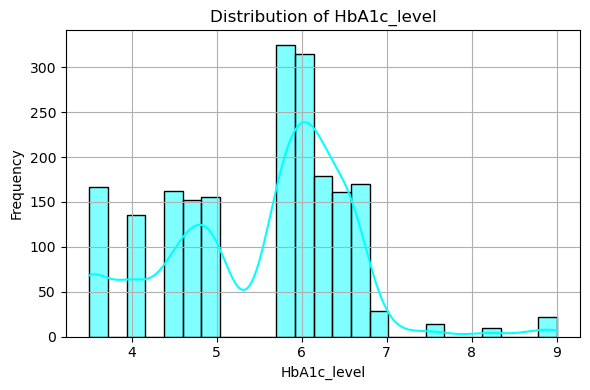

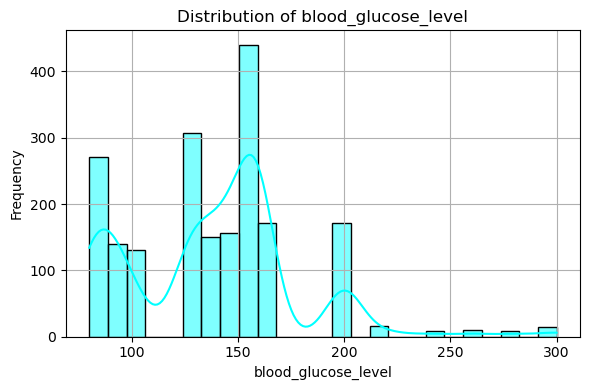

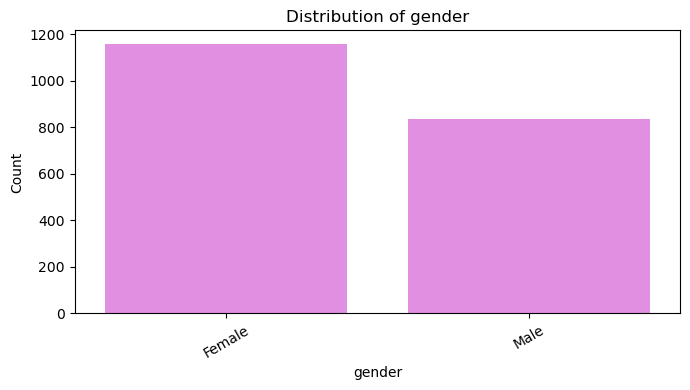

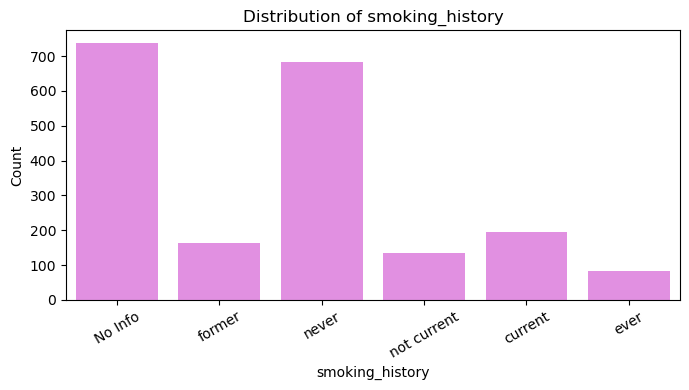

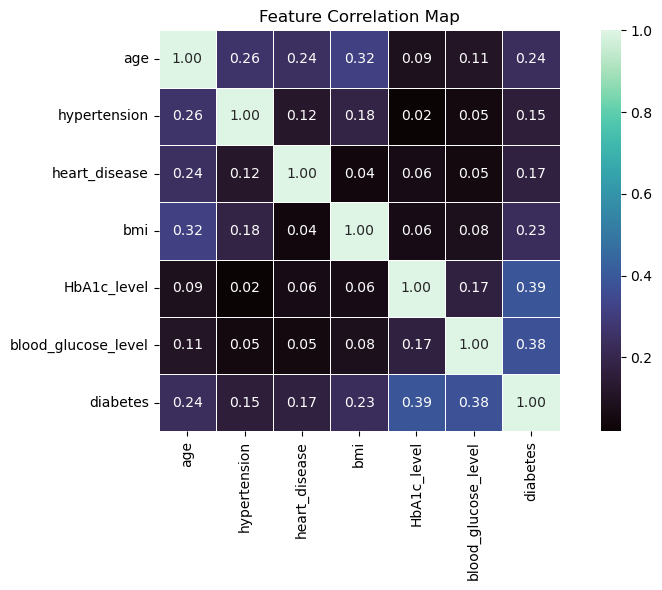

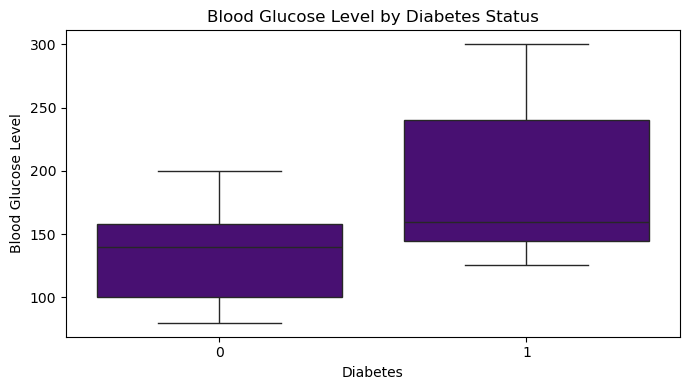

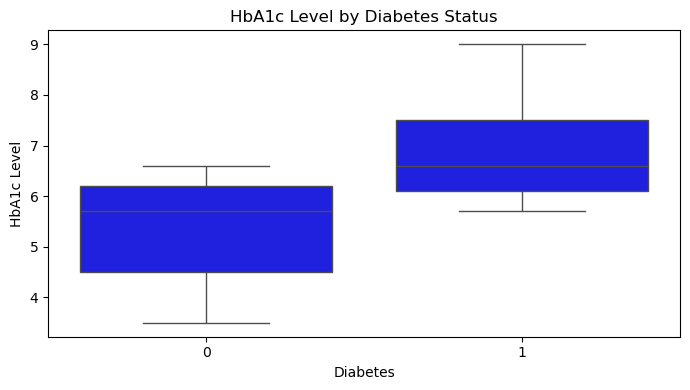

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



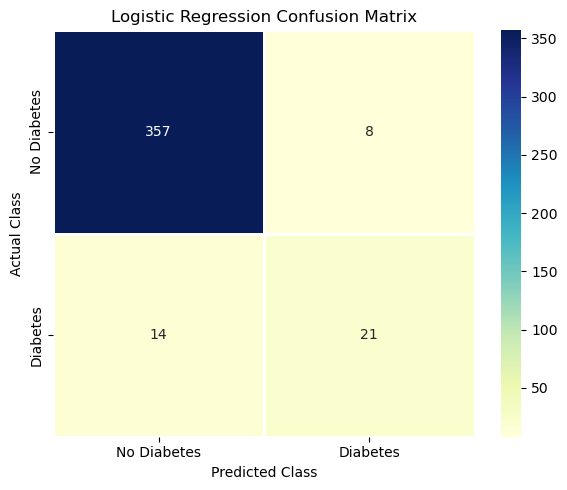

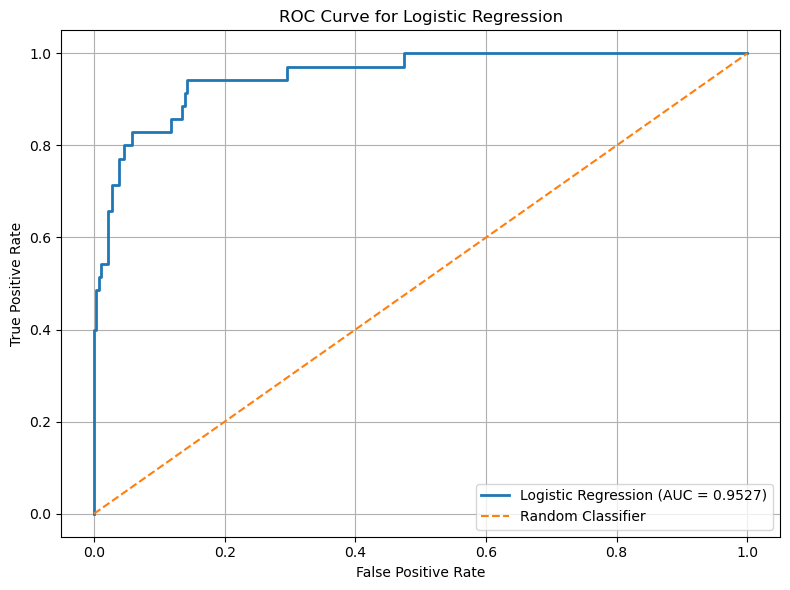

Model comparison


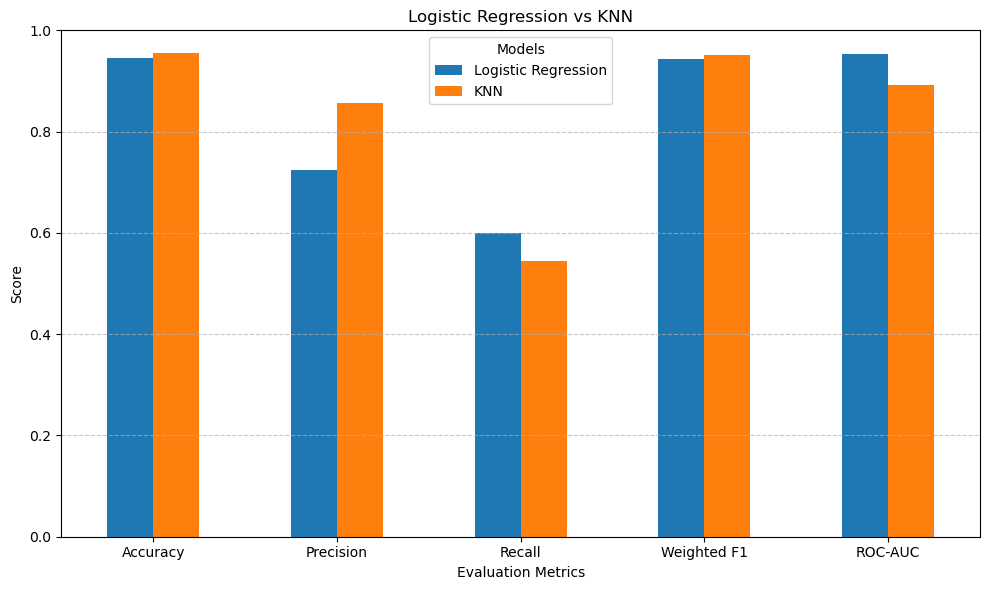

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


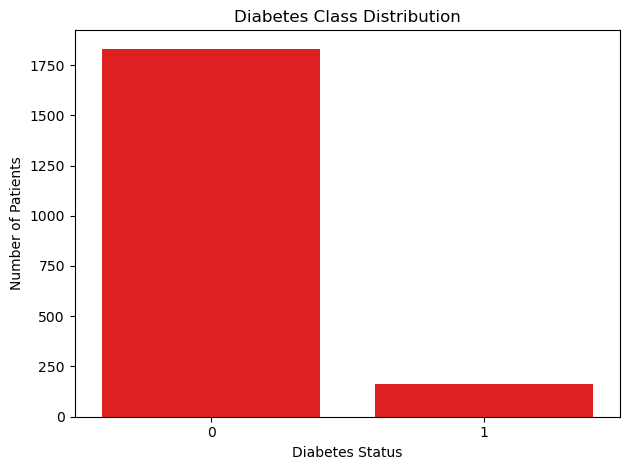

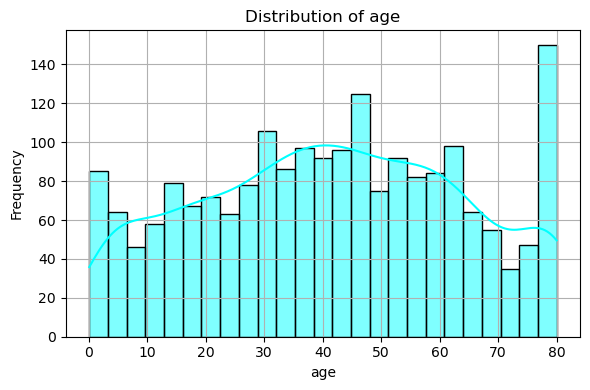

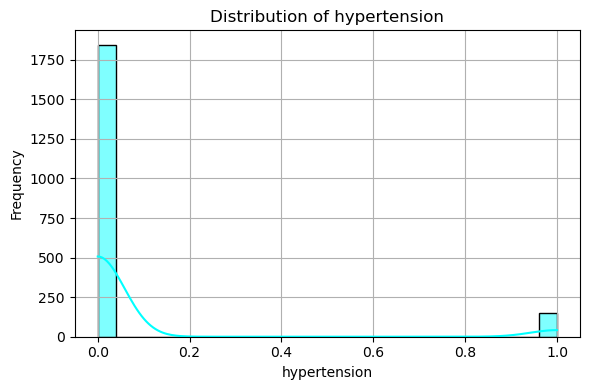

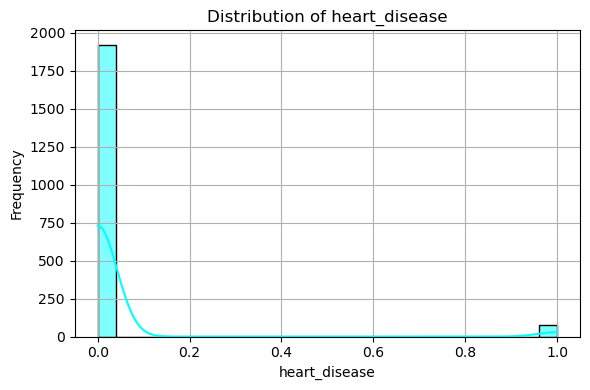

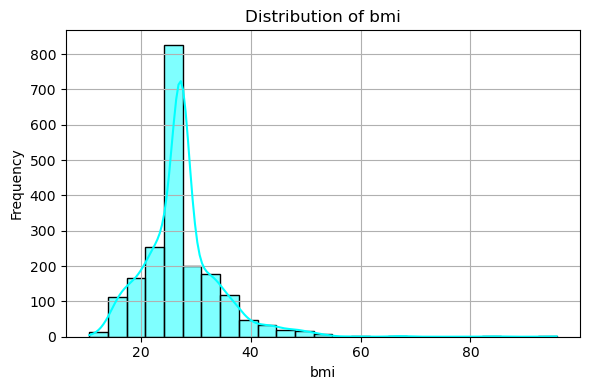

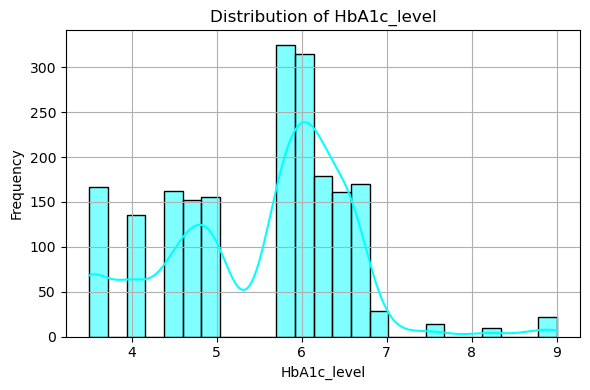

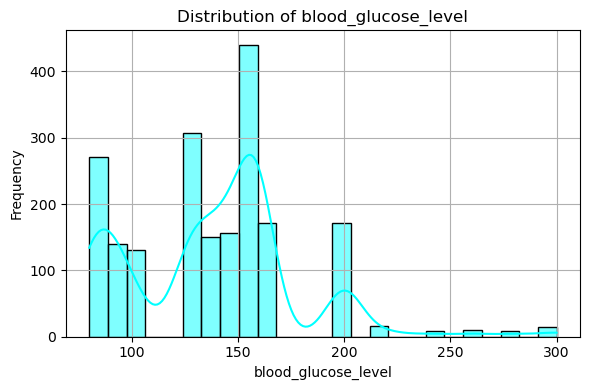

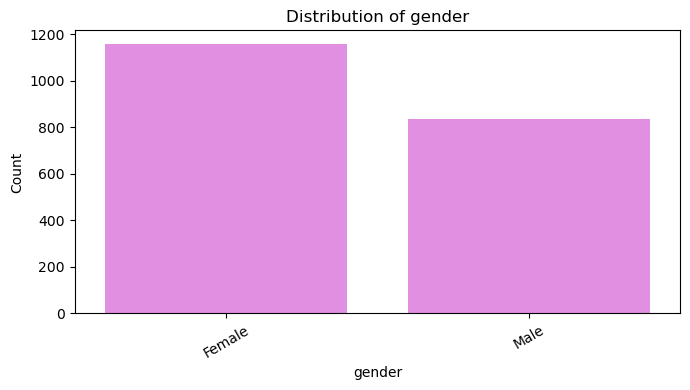

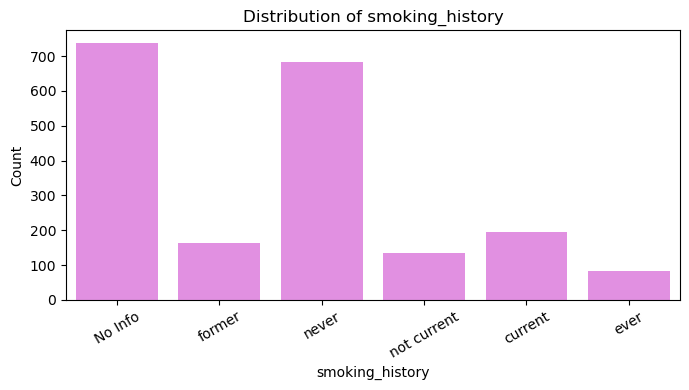

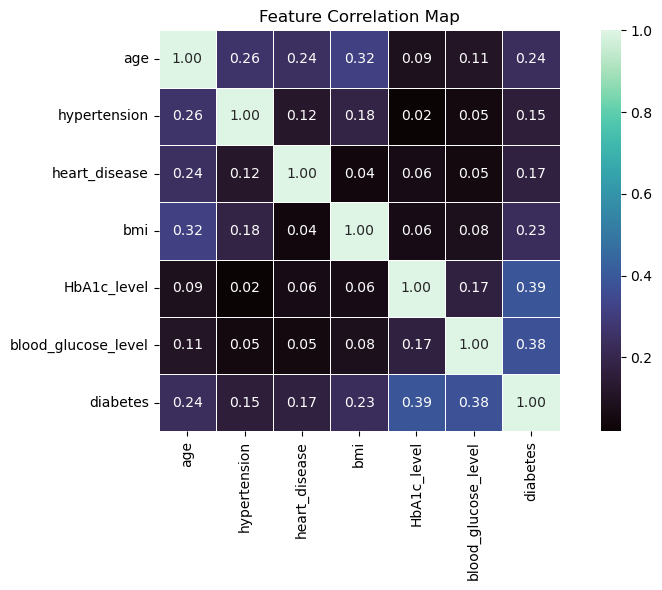

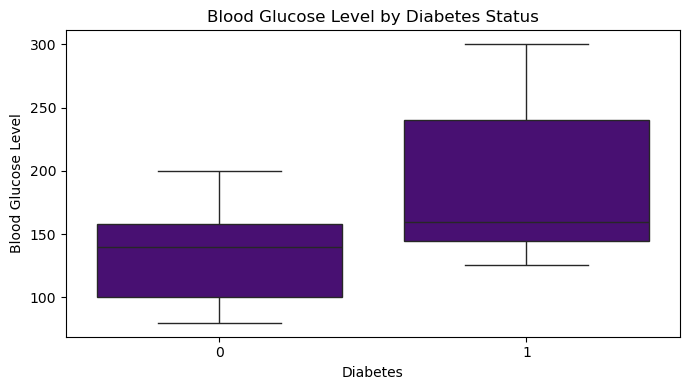

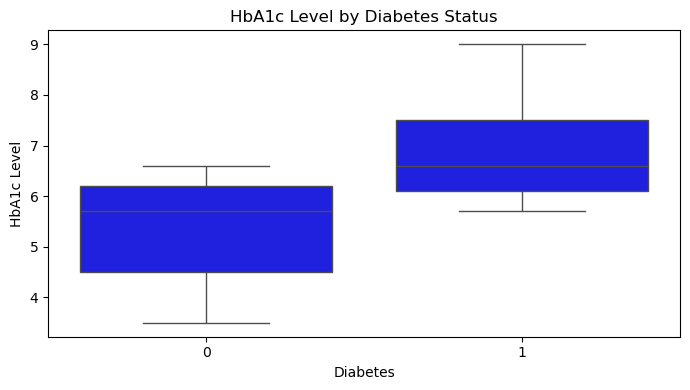

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



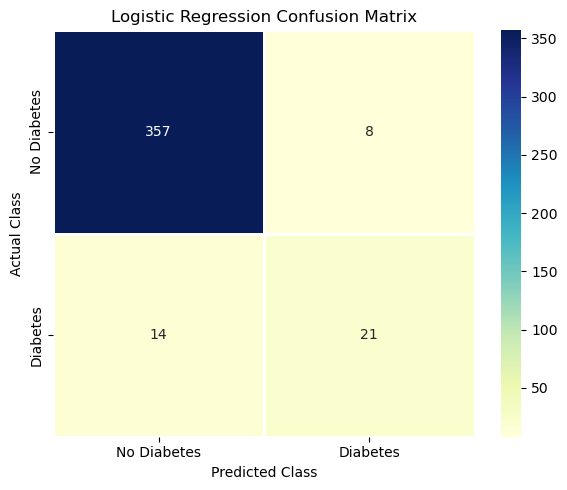

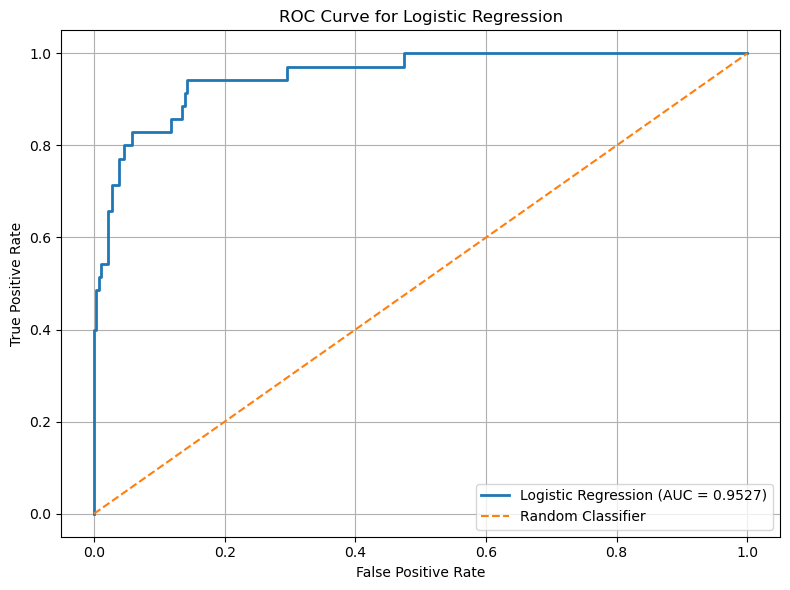

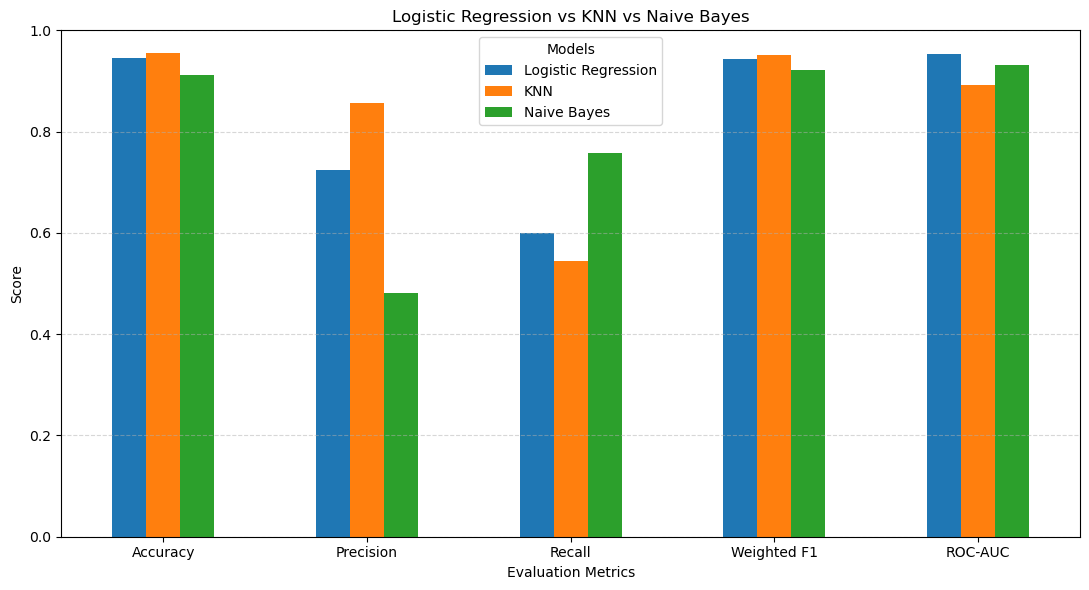

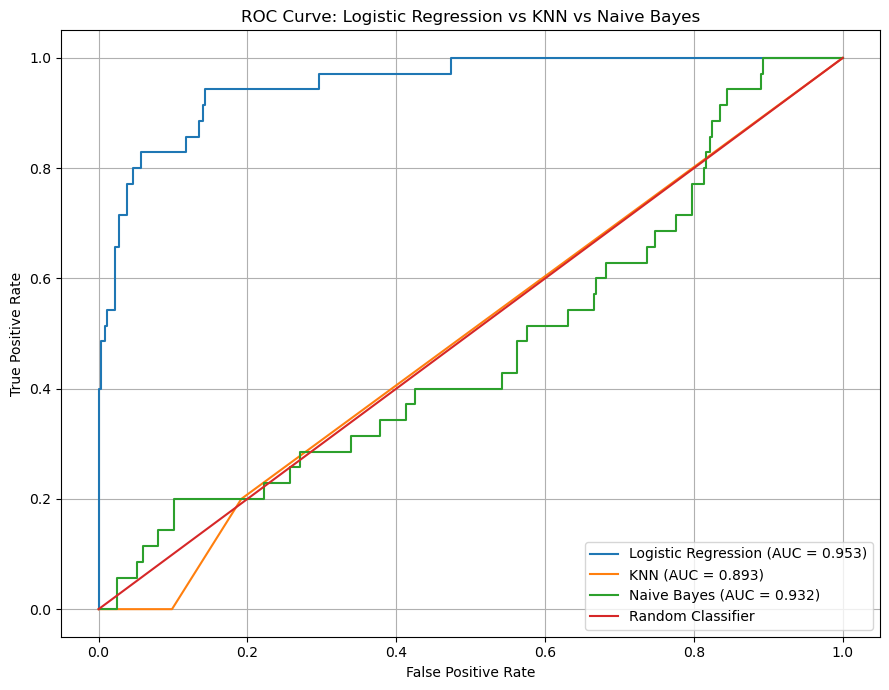

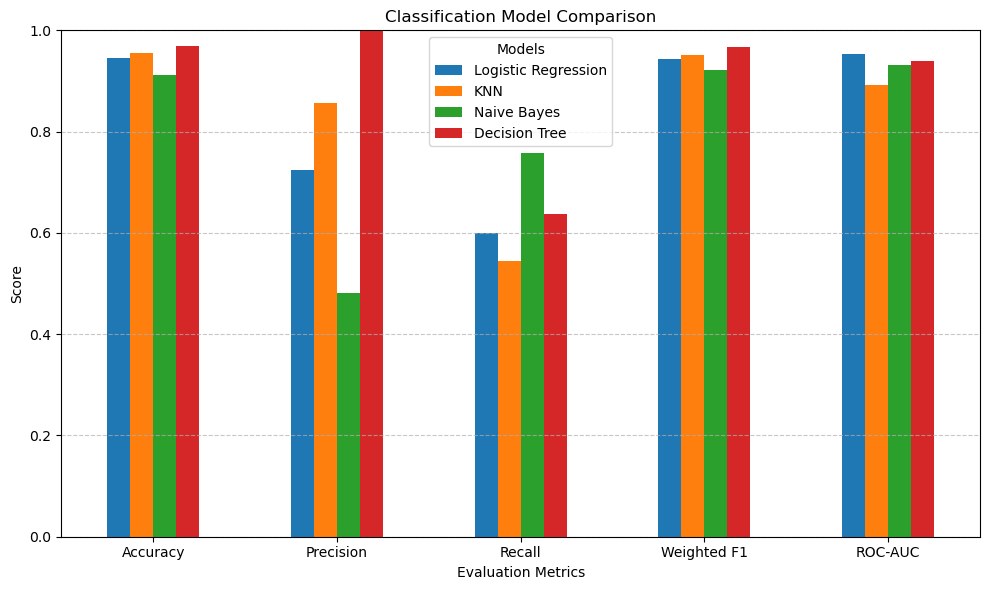

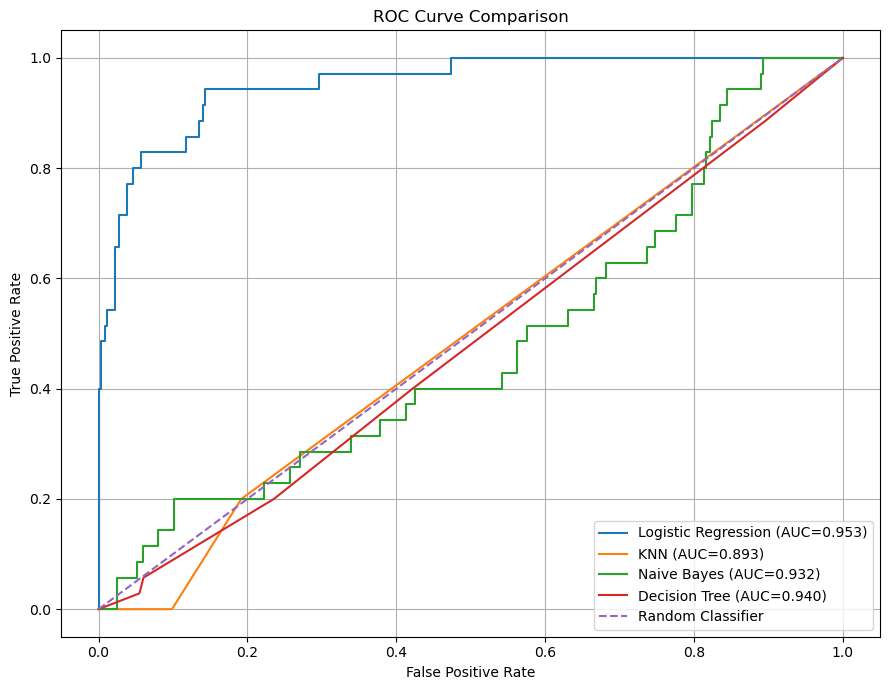

In [24]:
%run "classification4_DT.ipynb"

In [25]:
dt_results={"Accuracy":dt_accuracy,"Precision":dt_precision,"Recall":dt_recall,"Weighted F1":dt_f1,"ROC-AUC":dt_auc}
dt_y_test=y_test.copy()
dt_prob_saved=dt_prob.copy()

In [26]:
svm_results={"Accuracy":svm_accuracy,"Precision":svm_precision,"Recall":svm_recall,"Weighted F1":svm_f1,"ROC-AUC":svm_auc}
svm_y_test=y_test.copy()
svm_prob_saved=svm_prob.copy()

In [27]:
# Model comparison
comparison=pd.DataFrame({
    "Metrics":["Accuracy","Precision","Recall","Weighted F1","ROC-AUC"],
    "Logistic Regression":[lr_results["Accuracy"],lr_results["Precision"],lr_results["Recall"],lr_results["Weighted F1"],lr_results["ROC-AUC"]],
    "KNN":[knn_results["Accuracy"],knn_results["Precision"],knn_results["Recall"],knn_results["Weighted F1"],knn_results["ROC-AUC"]],
    "Naive Bayes":[nb_results["Accuracy"],nb_results["Precision"],nb_results["Recall"],nb_results["Weighted F1"],nb_results["ROC-AUC"]],
    "Decision Tree":[dt_results["Accuracy"],dt_results["Precision"],dt_results["Recall"],dt_results["Weighted F1"],dt_results["ROC-AUC"]],
    "SVM":[svm_results["Accuracy"],svm_results["Precision"],svm_results["Recall"],svm_results["Weighted F1"],svm_results["ROC-AUC"]]
})
comparison

,Metrics,Logistic Regression,KNN,Naive Bayes,Decision Tree,SVM
0,Accuracy,0.945000,0.955000,0.912500,0.970000,0.957500
1,Precision,0.724138,0.857143,0.480769,1.000000,0.952381
2,Recall,0.600000,0.545455,0.757576,0.636364,0.555556
3,Weighted F1,0.942646,0.950362,0.921117,0.966908,0.952337
4,ROC-AUC,0.952720,0.892783,0.931963,0.940013,0.957112


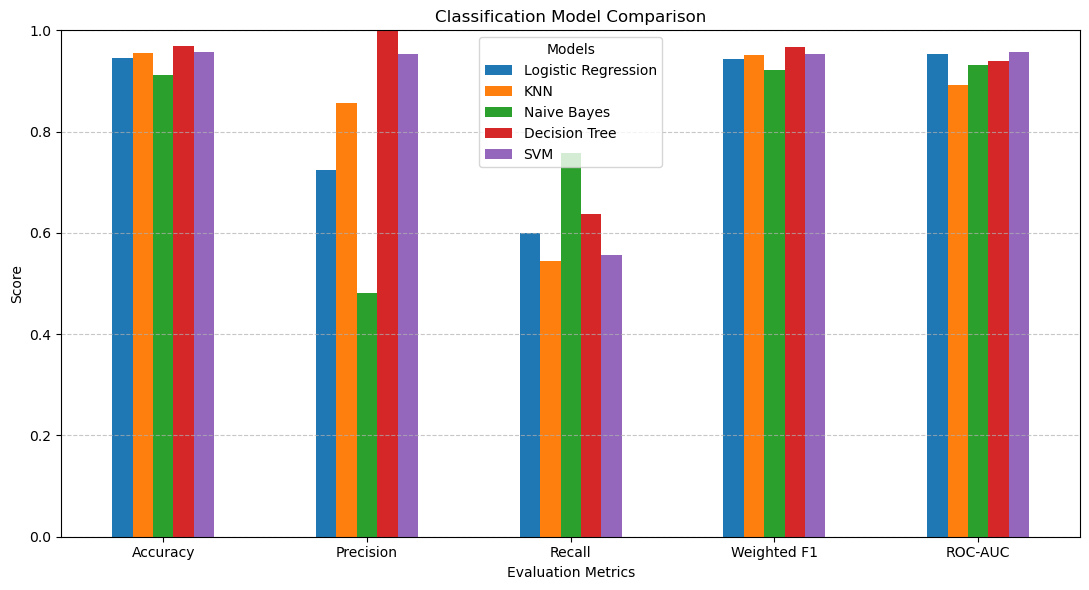

In [29]:
# Visualize model comparison
comparison.set_index("Metrics").plot(kind="bar",figsize=(11,6))
plt.title("Classification Model Comparison")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title="Models")
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.tight_layout()
plt.show()

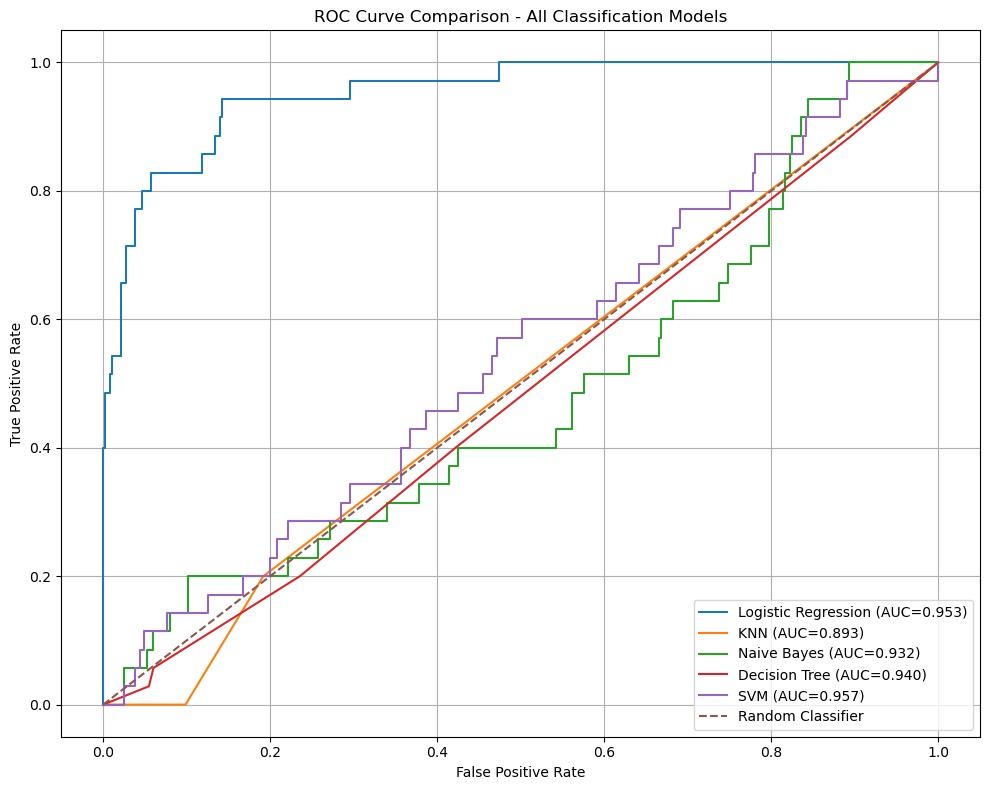

In [30]:
# ROC curve comparison
plt.figure(figsize=(10,8))

lr_fpr,lr_tpr,_=roc_curve(lr_y_test,lr_prob_saved)
knn_fpr,knn_tpr,_=roc_curve(knn_y_test,knn_prob_saved)
nb_fpr,nb_tpr,_=roc_curve(nb_y_test,nb_prob_saved)
dt_fpr,dt_tpr,_=roc_curve(dt_y_test,dt_prob_saved)
svm_fpr,svm_tpr,_=roc_curve(svm_y_test,svm_prob_saved)

plt.plot(lr_fpr,lr_tpr,label=f"Logistic Regression (AUC={lr_auc:.3f})")
plt.plot(knn_fpr,knn_tpr,label=f"KNN (AUC={knn_auc:.3f})")
plt.plot(nb_fpr,nb_tpr,label=f"Naive Bayes (AUC={nb_auc:.3f})")
plt.plot(dt_fpr,dt_tpr,label=f"Decision Tree (AUC={dt_auc:.3f})")
plt.plot(svm_fpr,svm_tpr,label=f"SVM (AUC={svm_auc:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Classification Models")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()